<span style="font-size:30px; color: olive">**Análisis de Medios de formación**</span>

<span style="font-size:14px">***Data source:*** <a href="https://www.mites.gob.es/es/estadisticas/mercado_trabajo/EAL/welcome.htm#">EAL</a></span>

# <span style="font-size:22px; color: orange">**1. Librerias**</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# <span style="font-size:22px; color: orange">**2. Carga de datos**</span>

In [2]:
# Cargar datos desde csv del repositorio de datos procesados
data_path="../../Data/processed/EAL_15062026/eal_formacion_unificado_largo.csv"
dataset = pd.read_csv(data_path)
dataset

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
0,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,De dirección,TOTAL,39.910
1,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,De trabajo en equipo,TOTAL,58.868
2,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,De atención al público/ trato a clientes,TOTAL,49.737
3,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,Administrativas de oficina,TOTAL,17.702
4,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,Técnicas específicas del puesto de trabajo,TOTAL,23.850
...,...,...,...,...,...,...,...
9898,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La empresa prefirió tener personal con contrat...,NaN,MUCHO,1.792
9899,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,El mayor esfuerzo realizado en años anteriores...,NaN,MUCHO,4.502
9900,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La elevada carga de trabajo y el escaso tiempo...,NaN,MUCHO,17.522
9901,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,Dificultad para acceder a ayudas o subvencione...,NaN,MUCHO,12.699


In [3]:
medios=dataset[(dataset['tabla']=='EAL-17')]

In [4]:
medios

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
78,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",total_empresas,TOTAL,TOTAL,100.000
79,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 5 a 9 trabajadores,TOTAL,100.000
80,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 10 a 49 trabajadores,TOTAL,100.000
81,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 50 a 249 trabajadores,TOTAL,100.000
82,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 250 a 499 trabajadores,TOTAL,100.000
...,...,...,...,...,...,...,...
8043,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Madrid (Comunidad de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,27.009
8044,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Murcia (Región de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,23.066
8045,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Navarra (Comunidad Foral de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,21.157
8046,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,País Vasco,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,28.829


## <span style="font-size:18px; color: orange">**2.1 Dividimos el dataset en 3 df independientes**</span>

   - <span style="font-size:14px">**Separamos el dataset en 3 df independientes, uno para `tamaño de empresa`, otro para `actividad económica` y otro para `comunidad autónoma`, para poder hacer un análisis más detallado de cada uno de ellos.**</span>

In [5]:
medios_tamaño_empresa = medios[(medios['ambito'] == 'total_empresas') | (medios['ambito']=='tamano_empresa')]
medios_sector = medios[medios['ambito'] == 'sector']
medios_comunidad_autonoma = medios[medios['ambito'] == 'ccaa']

In [6]:
print ("="*80)
print ("Información del DataFrame de medios por tamaño de empresa:")
print ("="*80)
medios_tamaño_empresa.info()
print ("="*80)
print ("Información del DataFrame de medios por sector:")
print ("="*80)
medios_sector.info()
print ("="*80)
print ("Información del DataFrame de medios por comunidad autónoma:")
print ("="*80)
medios_comunidad_autonoma.info()

Información del DataFrame de medios por tamaño de empresa:
<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 78 to 8021
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anio        180 non-null    int64  
 1   tabla       180 non-null    object 
 2   pregunta    180 non-null    object 
 3   ambito      180 non-null    object 
 4   categoria   180 non-null    object 
 5   variable    180 non-null    object 
 6   porcentaje  180 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 11.2+ KB
Información del DataFrame de medios por sector:
<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 84 to 8030
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anio        270 non-null    int64  
 1   tabla       270 non-null    object 
 2   pregunta    270 non-null    object 
 3   ambito      270 non-null    object 
 4   categori

# <span style="font-size:20px; color: orange">**3. Analizamos según TAMAÑO EMPRESA**</span>

<span style="font-size:14px">Analizamos los medios segun tamaño de la empresa, **filtrando** los datos para quedarnos solo con aquellas empresas que tienen características similares a la nuestra.</span>

In [7]:
medios_tamaño_empresa

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
78,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",total_empresas,TOTAL,TOTAL,100.000
79,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 5 a 9 trabajadores,TOTAL,100.000
80,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 10 a 49 trabajadores,TOTAL,100.000
81,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 50 a 249 trabajadores,TOTAL,100.000
82,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 250 a 499 trabajadores,TOTAL,100.000
...,...,...,...,...,...,...,...
8017,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 5 a 9 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,34.681
8018,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 10 a 49 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,20.772
8019,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 50 a 249 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,5.241
8020,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 250 a 499 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,1.629


In [8]:
#Cuales son nuestras variables y cuantas observaciones tenemos de cada una
medios_tamaño_empresa.groupby('variable').count().sort_values(by='variable', ascending=False)

,anio,tabla,pregunta,ambito,categoria,porcentaje
variable,,,,,,
TOTAL,30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL,30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO OTROS TIPOS DE FORMACIÓN (1),30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO IMPARTICIÓN DE CURSOS (1),30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - IMPARTICIÓN DE CURSOS Y OTROS TIPOS DE FORMACIÓN (1),30,30,30,30,30,30
EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,30,30,30,30,30,30


In [9]:
#Filtramos por aquellas empresas que tienen caracteristicas similares a la nuestra, es decir, >499 empleados
medios_tamaño_empresa_grandes = medios_tamaño_empresa[medios_tamaño_empresa['categoria']=='Más de 499 trabajadores']
medios_tamaño_empresa_grandes

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
83,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,TOTAL,100.000
115,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL,98.119
147,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - IMPARTIC...,90.160
179,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO IMP...,8.882
211,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO OTR...,0.958
243,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,1.881
1697,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,TOTAL,100.000
1729,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL,97.587
1761,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - IMPARTIC...,86.219
1793,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO IMP...,12.160


In [10]:
medios_tamaño_empresa_grandes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 83 to 8021
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anio        30 non-null     int64  
 1   tabla       30 non-null     object 
 2   pregunta    30 non-null     object 
 3   ambito      30 non-null     object 
 4   categoria   30 non-null     object 
 5   variable    30 non-null     object 
 6   porcentaje  30 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 1.9+ KB


### <span style="font-size:18px; color: rgb(218, 178, 164)">**3.1 Mapeo Jerárquico de variables**</span>

   - <span style="font-size:14px"> 100% empresas del año
├── Empresas que proporcionaron formación
│ ├── Cursos y otros tipos de formación
│ ├── Solo cursos
│ └── Solo otros tipos de formación
└── Empresas que no proporcionaron formación </span>

In [11]:
def clasificar_categoria(variable):
    v = str(variable).strip().upper()

    if v == "TOTAL":
        return "total_anual"
    elif v == "EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL":
        return "si_formacion_total"
    elif "NO PROPORCIONAN FORMACIÓN" in v:
        return "no_formacion"
    elif "SÓLO OTROS TIPOS DE FORMACIÓN" in v:
        return "solo_otros"
    elif "SÓLO IMPARTICIÓN DE CURSOS" in v:
        return "solo_cursos"
    elif "IMPARTICIÓN DE CURSOS Y OTROS TIPOS DE FORMACIÓN" in v:
        return "cursos_y_otros"
    else:
        return "otra"

In [12]:
medios_tamaño_empresa_grandes = medios_tamaño_empresa_grandes.copy()

medios_tamaño_empresa_grandes.loc[:, "categoria_analitica"] = (
    medios_tamaño_empresa_grandes["variable"].apply(clasificar_categoria)
)

cats_validas = [
    "total_anual",
    "si_formacion_total",
    "no_formacion",
    "cursos_y_otros",
    "solo_cursos",
    "solo_otros"
]

df_analisis_empresa = medios_tamaño_empresa_grandes.loc[
    medios_tamaño_empresa_grandes["categoria_analitica"].isin(cats_validas)
].copy()

df_analisis_empresa = df_analisis_empresa.loc[
    :, ["anio", "variable", "categoria_analitica", "porcentaje"]    #Mantenemos 'variable' para comprobar que la categorización es correcta
].sort_values(["anio", "categoria_analitica"])

   - <span style="font-size:14px; color: rgb(144, 170, 38)"> **Generamos una matriz año por categoría analítica**. Esto nos permitirá ver la evolución de cada categoría a lo largo del tiempo y detectar tendencias. </span>

In [13]:
tabla_matriz = (
    df_analisis_empresa
    .pivot_table(
        index="anio",
        columns="categoria_analitica",
        values="porcentaje",
        aggfunc="first"
    )
    .reset_index()
)

tabla_matriz

categoria_analitica,anio,cursos_y_otros,no_formacion,si_formacion_total,solo_cursos,solo_otros,total_anual
0,2020,90.160,1.881,98.119,8.882,0.958,100.0
1,2021,86.219,2.413,97.587,12.160,1.621,100.0
2,2022,90.344,1.298,98.702,8.464,1.192,100.0
3,2023,90.515,0.716,99.284,8.876,0.608,100.0
4,2024,88.305,0.702,99.298,9.742,1.953,100.0


<span style="font-size:14px">Reordenamos las columnas de la matriz para que aparezcan en el orden deseado: `no_formacion`,`si_formacion_total`, `solo_cursos`, `cursos_y_otros`, `solo_otros` y `total_anual`.</span>

In [14]:
# Cambiamos los nombre para adapatarlos a los que queremos
tabla_matriz=tabla_matriz.rename(columns={
    "anio": "Año",
    "no_formacion": "No Formación",
    "si_formacion_total": "Sí Formación (Total)",
    "solo_cursos": "Solo Cursos",
    "cursos_y_otros": "Cursos y Otros",
    "solo_otros": "Solo Otros",
    "total_anual": "Total Anual"
})

tabla_matriz = tabla_matriz.reindex(columns=["Año",
                                             "No Formación",
                                             "Sí Formación (Total)",
                                             "Solo Cursos",
                                             "Cursos y Otros",
                                             "Solo Otros",
                                             "Total Anual"])

tabla_matriz


categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
0,2020,1.881,98.119,8.882,90.160,0.958,100.0
1,2021,2.413,97.587,12.160,86.219,1.621,100.0
2,2022,1.298,98.702,8.464,90.344,1.192,100.0
3,2023,0.716,99.284,8.876,90.515,0.608,100.0
4,2024,0.702,99.298,9.742,88.305,1.953,100.0


#### <span style="font-size:18px; color: rgb(228, 204, 123)">**3.1.1 Validamos la jerárquia** </span>

<span style="font-size:14px"> Validamos que la jerarquía de las categorías analíticas sea correcta, es decir, que la suma de las categorías cumpla lo esperado. De este modo, podemos detectar errores en el mapeo de las categorias y datos </span>

In [15]:
#Quiero comprovar que la suma de 'solo cursos + 'cursos y otros' + 'solo otros' = 100 en todos los años
tabla_matriz["Suma Subcategorías"] = (
    tabla_matriz["Solo Cursos"] +
    tabla_matriz["Cursos y Otros"] +
    tabla_matriz["Solo Otros"]
).round()
tabla_matriz

categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,Suma Subcategorías
0,2020,1.881,98.119,8.882,90.160,0.958,100.0,100.0
1,2021,2.413,97.587,12.160,86.219,1.621,100.0,100.0
2,2022,1.298,98.702,8.464,90.344,1.192,100.0,100.0
3,2023,0.716,99.284,8.876,90.515,0.608,100.0,100.0
4,2024,0.702,99.298,9.742,88.305,1.953,100.0,100.0


## <span style="font-size:18px; color: orange">**3.2 Calculamos la evolución de cada categoría a lo largo del tiempo**</span>

<span style="font-size:14px;">Calculamos variación absoluta, relativa, índice base 100 y CAGR. Esto nos permite analizar cómo evolucionan las diferentes categorías a lo largo del tiempo.</span>

In [97]:
def calcular_indicadores_serie(s):
    s = s.dropna().sort_index()
    return {
        "valor_inicial": s.iloc[0],
        "valor_final": s.iloc[-1],
        "variacion_absoluta_pp": s.iloc[-1] - s.iloc[0],
        "variacion_relativa_pct": ((s.iloc[-1] 
                                    - s.iloc[0]) / 
                                    s.iloc[0] * 100) 
                                    if s.iloc[0] != 0 
                                    else np.nan,
        "cagr_pct": (((s.iloc[-1]                   #Calculamos el CAGR (Compound Annual Growth Rate) para la serie temporal
                       / s.iloc[0]) ** (1 / (len(s) - 1)) - 1) * 100) 
                       if s.iloc[0] > 0 and len(s) > 1 
                       else np.nan,
        "min": s.min(),
        "max": s.max(),
        "rango": s.max() - s.min(),
        "media_periodo": s.mean(),          #media de los valores de la serie durante el periodo analizado
        "std_periodo": s.std()              #desviación estándar de los valores de la serie durante el periodo analizado
    }


In [17]:
resumen_metricas = pd.DataFrame({
    col: calcular_indicadores_serie(tabla_matriz.set_index("Año")[col])
    for col in [
        "No Formación",
        "Sí Formación (Total)",
        "Solo Cursos",
        "Cursos y Otros",
        "Solo Otros"
    ]
}).T.reset_index().rename(columns={"index": "indicador"})

resumen_metricas.round(3)

,indicador,valor_inicial,valor_final,variacion_absoluta_pp,variacion_relativa_pct,cagr_pct,min,max,rango,media_periodo,std_periodo
0,No Formación,1.881,0.702,-1.179,-62.679,-21.840,0.702,2.413,1.711,1.402,0.745
1,Sí Formación (Total),98.119,99.298,1.179,1.202,0.299,97.587,99.298,1.711,98.598,0.745
2,Solo Cursos,8.882,9.742,0.860,9.683,2.337,8.464,12.160,3.696,9.625,1.492
3,Cursos y Otros,90.160,88.305,-1.855,-2.057,-0.518,86.219,90.515,4.296,89.109,1.844
4,Solo Otros,0.958,1.953,0.995,103.862,19.491,0.608,1.953,1.345,1.266,0.532


<span style="font-size:14px; color: red">**Observación:**</span> <span style="font-size:14px">Entre 2020 y 2024, las empresas de más de 499 trabajadores muestran una consolidación de la cobertura formativa, con descenso de las empresas sin formación y aumento de las que sí forman. Dentro del grupo formador, la ***modalidad mixta sigue siendo mayoritaria***, aunque pierde algo de peso frente a “Solo Cursos” y “Solo Otros</span>

### <span style="font-size:18px; color: orange">**3.2.1 Variación interanual**</span>

<span style="font-size:14px">Calculamos la variación interanual de cada categoría, es decir, la diferencia entre el valor de un año y el valor del año anterior. Esto nos permite ver cómo evolucionan las diferentes categorías de un año a otro. **Nos permite saber si el cambio fue gradual o concentrado en años concretos**</span>

In [18]:
tabla_año = tabla_matriz.copy().sort_values("Año")

cols = [
    "No Formación",
    "Sí Formación (Total)",
    "Solo Cursos",
    "Cursos y Otros",
    "Solo Otros"
]

for col in cols:
    tabla_año[f"{col}_diff_pp"] = tabla_año[col].diff()
    tabla_año[f"{col}_pct_change"] = tabla_año[col].pct_change() * 100

tabla_año.round(3)

categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,Suma Subcategorías,No Formación_diff_pp,No Formación_pct_change,Sí Formación (Total)_diff_pp,Sí Formación (Total)_pct_change,Solo Cursos_diff_pp,Solo Cursos_pct_change,Cursos y Otros_diff_pp,Cursos y Otros_pct_change,Solo Otros_diff_pp,Solo Otros_pct_change
0,2020,1.881,98.119,8.882,90.160,0.958,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,2.413,97.587,12.160,86.219,1.621,100.0,100.0,0.532,28.283,-0.532,-0.542,3.278,36.906,-3.941,-4.371,0.663,69.207
2,2022,1.298,98.702,8.464,90.344,1.192,100.0,100.0,-1.115,-46.208,1.115,1.143,-3.696,-30.395,4.125,4.784,-0.429,-26.465
3,2023,0.716,99.284,8.876,90.515,0.608,100.0,100.0,-0.582,-44.838,0.582,0.590,0.412,4.868,0.171,0.189,-0.584,-48.993
4,2024,0.702,99.298,9.742,88.305,1.953,100.0,100.0,-0.014,-1.955,0.014,0.014,0.866,9.757,-2.210,-2.442,1.345,221.217


<span style="font-size:14px; color:red">**Observación:** </span><span style="font-size:14px">La evolución interanual muestra una reducción progresiva de las empresas sin formación y un aumento paralelo de las empresas que sí forman. Dentro del grupo formador, las submodalidades presentan variaciones moderadas, con **predominio estable de la formación mixta (Cursos y Otros)**, aunque en 2024 se observa un ligero desplazamiento hacia modalidades más simples o específicas.</span>

## <span style="font-size: 18px; color: orange">**Visualizaciones**</span>

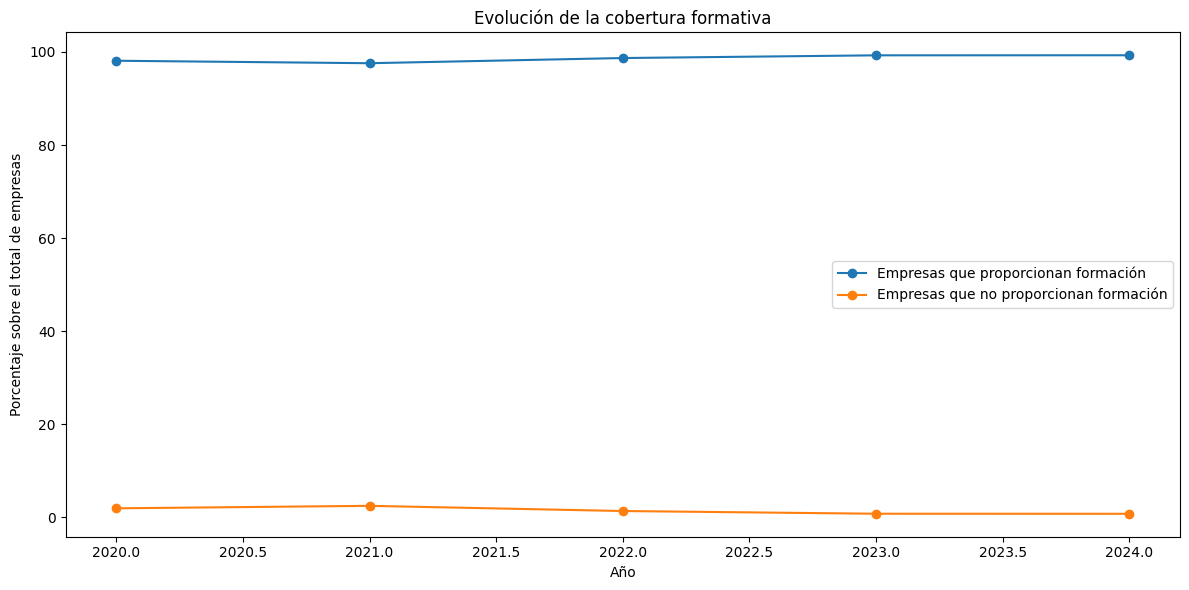

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(tabla_matriz["Año"], tabla_matriz["Sí Formación (Total)"], marker="o", label="Empresas que proporcionan formación")
plt.plot(tabla_matriz["Año"], tabla_matriz["No Formación"], marker="o", label="Empresas que no proporcionan formación")
plt.title("Evolución de la cobertura formativa")
plt.xlabel("Año")
plt.ylabel("Porcentaje sobre el total de empresas")
plt.legend()
plt.tight_layout()
plt.show()

<span style="font-size:16px; color: rgba(92, 234, 186, 0.99)">**Línea temporal de la evolución** de la cobertura formativa y de las modalidades formativas</span>

<Figure size 1000x600 with 0 Axes>

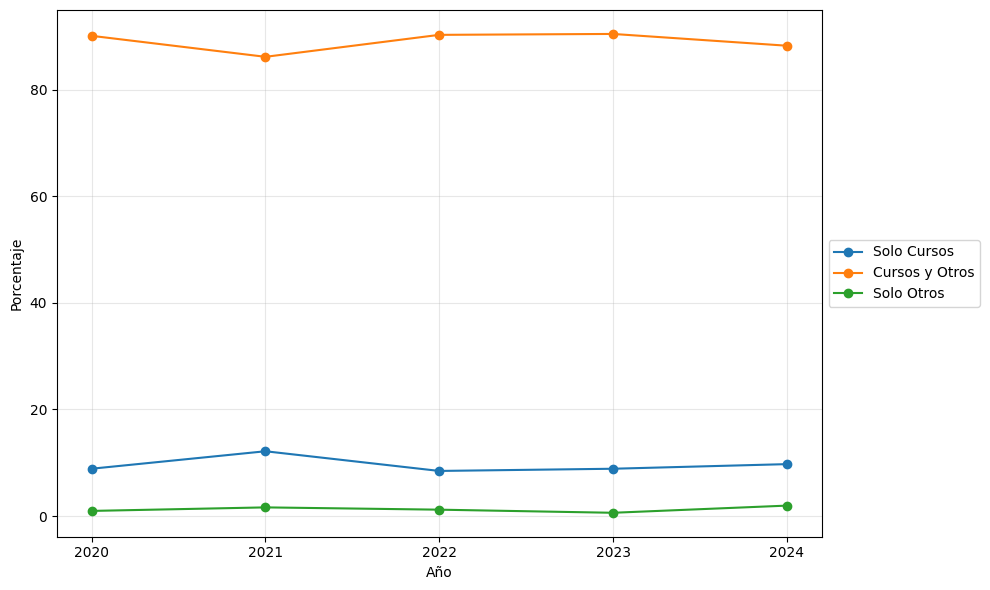

In [ ]:
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_alpha(0)     # fondo de la figura transparente
ax.set_facecolor("none")   # fondo del área del gráfico transparente

plt.plot(tabla_matriz["Año"], tabla_matriz["Solo Cursos"],
         marker="o",
         label="Solo Cursos")
plt.plot(tabla_matriz["Año"], tabla_matriz["Cursos y Otros"],
         marker="o",
         label="Cursos y Otros")
plt.plot(tabla_matriz["Año"], tabla_matriz["Solo Otros"],
         marker="o",
         label="Solo Otros")

plt.title("Evolución de las modalidades formativas")
plt.xlabel("Año")
plt.ylabel("Porcentaje")
plt.xticks(tabla_matriz["Año"].astype(int))

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))  # leyenda fuera
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

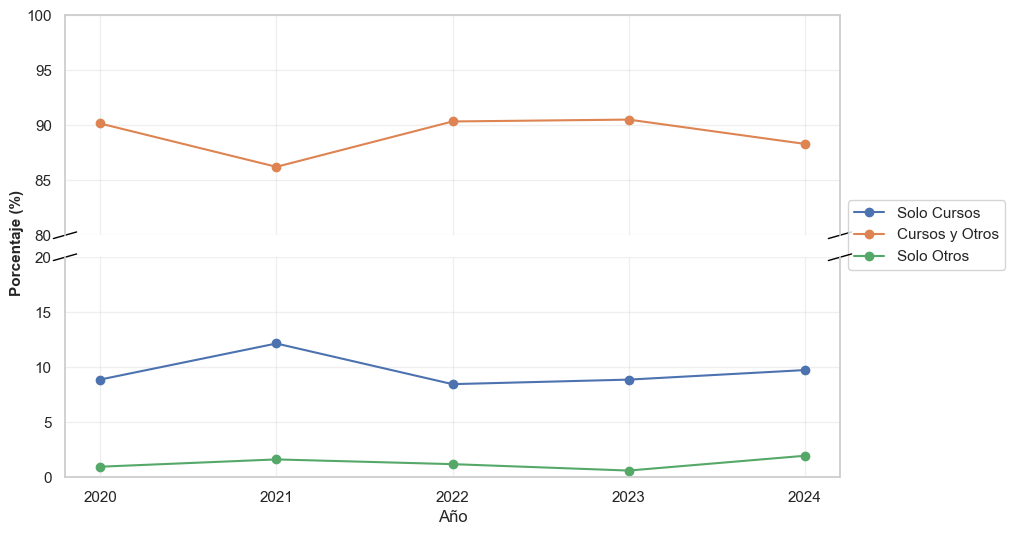

In [ ]:
# 1. Crear la figura con dos subgráficos compartiendo el eje X (arriba y abajo)
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6), gridspec_kw={"height_ratios": [1, 1]}
)
fig.subplots_adjust(hspace=0.1)  # Unir casi por completo ambos gráficos

# Configurar fondos transparentes
fig.patch.set_alpha(0)
ax_top.set_facecolor("none")
ax_bot.set_facecolor("none")

# 2. Graficar los datos exactamente IGUAL en ambos subgráficos
for ax in [ax_top, ax_bot]:
    ax.plot(
        tabla_matriz["Año"],
        tabla_matriz["Solo Cursos"],
        marker="o",
        label="Solo Cursos",
    )
    ax.plot(
        tabla_matriz["Año"],
        tabla_matriz["Cursos y Otros"],
        marker="o",
        label="Cursos y Otros",
    )
    ax.plot(
        tabla_matriz["Año"],
        tabla_matriz["Solo Otros"],
        marker="o",
        label="Solo Otros",
    )
    ax.grid(True, alpha=0.3)

# 3. Recortar los límites de cada eje Y para ocultar el espacio en blanco
ax_top.set_ylim(80, 100)  # Rango superior
ax_bot.set_ylim(0, 20)  # Rango inferior

# Ocultar las líneas divisorias internas del recuadro
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)  # Quitar marcas de ticks ocultas arriba

# 4. Dibujar las marcas de discontinuidad (líneas diagonales "//")
d = 0.015  # Tamaño de las marcas diagonales
kwargs = dict(transform=ax_top.transAxes, color="black", clip_on=False, lw=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)  # Marca diagonal izquierda superior
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Marca diagonal derecha superior

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Marca diagonal izquierda inferior
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Marca diagonal derecha inferior

# 5. Títulos y etiquetas (Eje Y centrado globalmente)
ax_top.set_title("Evolución de las modalidades formativas", pad=15)
ax_bot.set_xlabel("Año")
ax_bot.set_xticks(tabla_matriz["Año"].astype(int))

# Etiqueta global del eje Y compartida en el centro
fig.text(
    0.07,
    0.5,
    "Porcentaje (%)",
    va="center",
    rotation="vertical",
    fontsize=11,
    fontweight="bold",
)

# 6. Leyenda única (tomada del gráfico superior)
handles, labels = ax_top.get_legend_handles_labels()
ax_top.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0))

plt.show()


<span style="font-size:16px; color: red">**Observación:**</span> <span style="font-size:14px">**¿Cómo forman las empresas con más de 499 empleados?** Podemos observar que el método que más se utiliza es la formación mixta (**Cursos y Otros**). Del año 2020-2021, observamos un disminución/caida en el método mixto de formación y un aumento en **Solo Cursos** seguramente por el confinamiento y la adaptación a la formación online.</span>

<span style="font-size:16px; color: rgba(92, 234, 186, 0.99)">**Barras horizontales**: cambio 2024 vs 2020</span>

   - <span style="font-size:14px; color: rgb(185, 91, 60)">**Por puntos porcentuales (pp)**.</span>

C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\1397552825.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cambio_2024_2020,


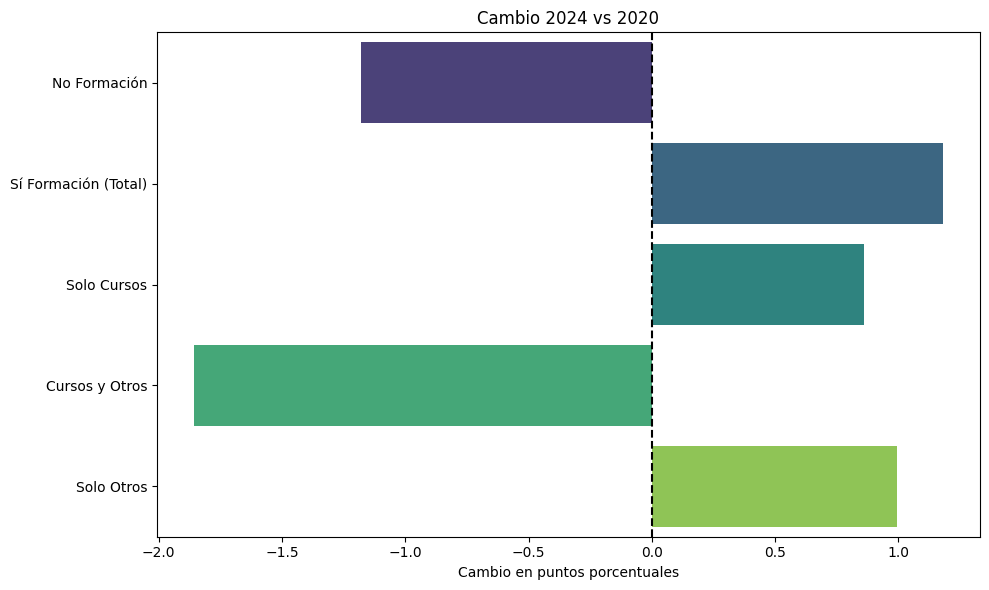

In [21]:
cambio_2024_2020 = pd.DataFrame({
    "indicador": ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"],
    "cambio_pp": [
        tabla_matriz["No Formación"].iloc[-1] - tabla_matriz["No Formación"].iloc[0],
        tabla_matriz["Sí Formación (Total)"].iloc[-1] - tabla_matriz["Sí Formación (Total)"].iloc[0],
        tabla_matriz["Solo Cursos"].iloc[-1] - tabla_matriz["Solo Cursos"].iloc[0],
        tabla_matriz["Cursos y Otros"].iloc[-1] - tabla_matriz["Cursos y Otros"].iloc[0],
        tabla_matriz["Solo Otros"].iloc[-1] - tabla_matriz["Solo Otros"].iloc[0],
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=cambio_2024_2020,
            x="cambio_pp",
            y="indicador",
            palette="viridis")

plt.axvline(0, color="black", linestyle="--")
plt.title("Cambio 2024 vs 2020")
plt.xlabel("Cambio en puntos porcentuales")
plt.ylabel("")
plt.tight_layout()
plt.show()

   - <span style="font-size:14px; color: rgb(185, 91, 60)">**Por porcentajes relativos (pct)**.</span>

<span style="font-size:16px; color: red">**Ojo con la interpretación del resultado:**</span> <span style="font-size:14px">En nuestro caso, ***Solo Otros*** puede salir con un cambio relativo muy grande porque parte de un valor inicial muy pequeño. Eso no significa necesariamente que sea una categoría dominante; solo que ha crecido mucho en relación con su base inicial.</span>

C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\3965219959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cambio_2024_2020, x="cambio_relativo_pct", y="indicador", palette="viridis")


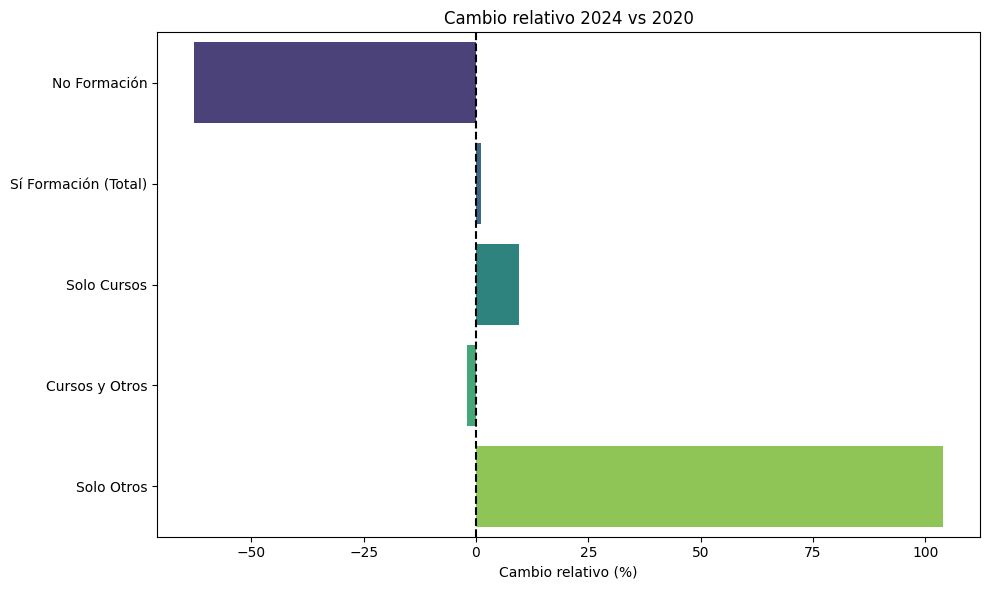

In [22]:
indicadores = ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]

cambio_2024_2020 = pd.DataFrame({
    "indicador": indicadores,
    "cambio_relativo_pct": [
        (tabla_matriz[col].iloc[-1] - tabla_matriz[col].iloc[0]) / tabla_matriz[col].iloc[0] * 100
        for col in indicadores
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=cambio_2024_2020, x="cambio_relativo_pct", y="indicador", palette="viridis")
plt.axvline(0, color="black", linestyle="--")
plt.title("Cambio relativo 2024 vs 2020")
plt.xlabel("Cambio relativo (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

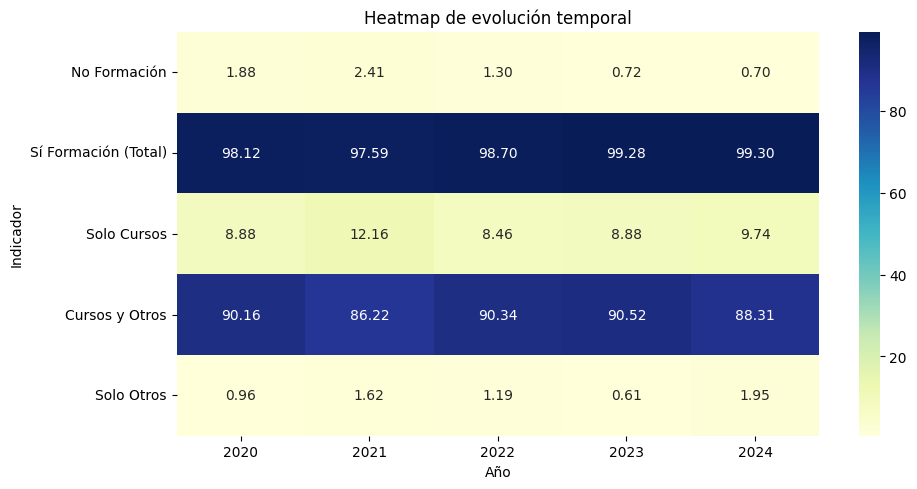

In [23]:
heatmap_df = tabla_matriz.set_index("Año")[
    ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]
]

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df.T, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap de evolución temporal")
plt.xlabel("Año")
plt.ylabel("Indicador")
plt.tight_layout()
plt.show()

## <span style="font-size:22px; color: orange">**3.3. Estadística**</span>

### <span style="font-size:18px; color: orange">**3.3.1 Wilcoxon pareado**</span>

   - <span style="font-size:14px; color: rgb(142, 209, 42)">**Solo Cursos vs Cursos y Otros**</span>

<span style="font-size:14px">Solo nos sirve como prueba **exploratoria**, no como evidencia fuerte, porque estamos trabajando con porcentajes agregados y solo 5 años de datos. Sin embargo, nos permite ver si hay diferencias significativas entre las dos modalidades de formación.</span>

<span style="font-size:14px; color: rgb(142, 209, 42)">**Nota:**</span> <span style="font-size:14px">Nos dice si dos series/medios difieren sistemáticamente pero no si una crece en el tiempo</span>

In [24]:
from scipy.stats import wilcoxon
stat, p = wilcoxon(
    tabla_matriz["Cursos y Otros"],
    tabla_matriz["Solo Otros"]
)

print("Estadístico Wilcoxon:", stat)
print("p-valor:", p)

Estadístico Wilcoxon: 0.0
p-valor: 0.0625


In [25]:
stat, p = wilcoxon(
    tabla_matriz["Solo Cursos"],
    tabla_matriz["Solo Otros"]
)

print("Estadístico Wilcoxon:", stat)
print("p-valor:", p)

Estadístico Wilcoxon: 0.0
p-valor: 0.0625


<span style="font-size:14px; color: red">**La prueba de Wilcoxon arroja un estadístico de 0.0 y un p-valor de 0.0625. Aunque el resultado sugiere una tendencia consistente entre las series comparadas, no alcanza significación estadística al 5%, por lo que no se rechaza la hipótesis nula.**</span>

### <span style="font-size:18px; color: orange">**3.3.2 Regresión lineal temporal**</span>

In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np

def tendencia_lineal(df, columna):
    X = df[["Año"]]
    y = df[columna]

    modelo = LinearRegression()
    modelo.fit(X, y)

    pendiente = modelo.coef_[0]
    intercepto = modelo.intercept_
    r2 = modelo.score(X, y)
    pred = modelo.predict(X)

    print(f"\nVariable: {columna}")
    print(f"Pendiente anual: {pendiente:.4f}")
    print(f"Intercepto: {intercepto:.4f}")
    print(f"R²: {r2:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(df["Año"], y, marker="o", label="Valor real")
    plt.plot(df["Año"], pred,
             linestyle="--",
             label="Tendencia lineal")
    plt.title(f"Tendencia temporal - {columna}")
    plt.xlabel("Año")
    plt.ylabel("Porcentaje")
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.xticks(tabla_matriz["Año"].astype(int))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Variable: No Formación
Pendiente anual: -0.4055
Intercepto: 821.3230
R²: 0.7397


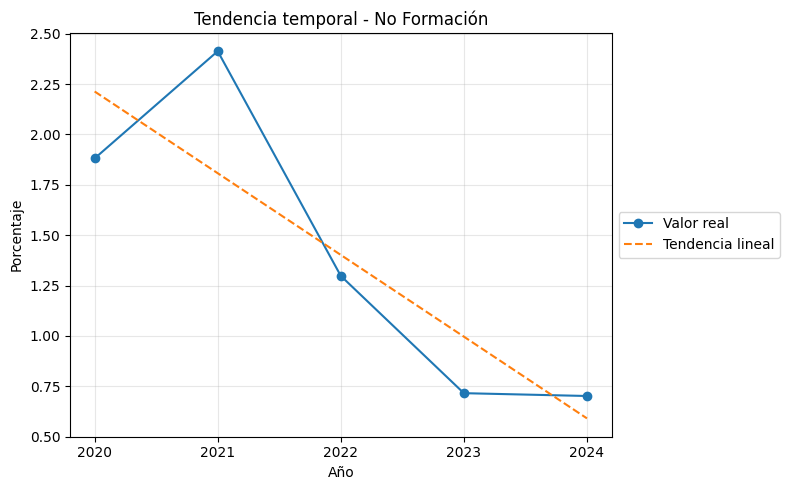


Variable: Sí Formación (Total)
Pendiente anual: 0.4055
Intercepto: -721.3230
R²: 0.7397


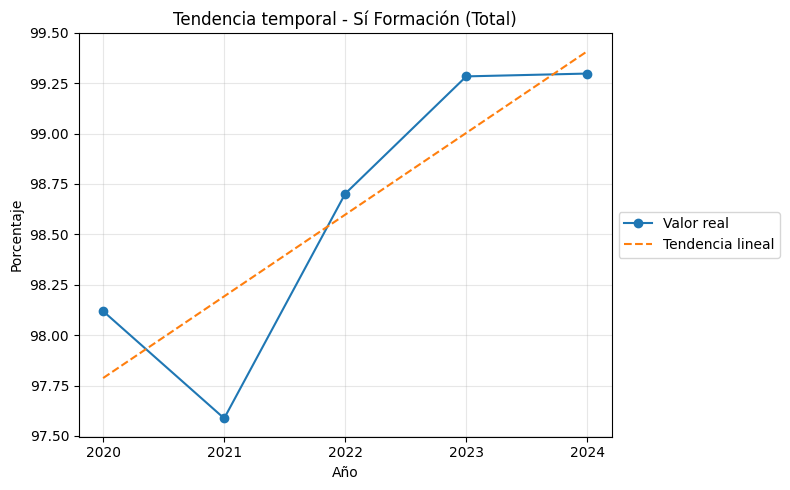


Variable: Solo Cursos
Pendiente anual: -0.1564
Intercepto: 325.8656
R²: 0.0275


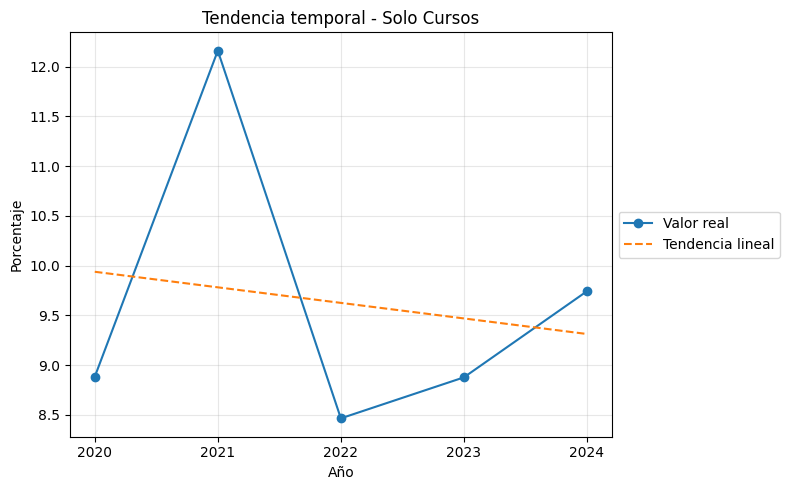


Variable: Cursos y Otros
Pendiente anual: 0.0586
Intercepto: -29.3806
R²: 0.0025


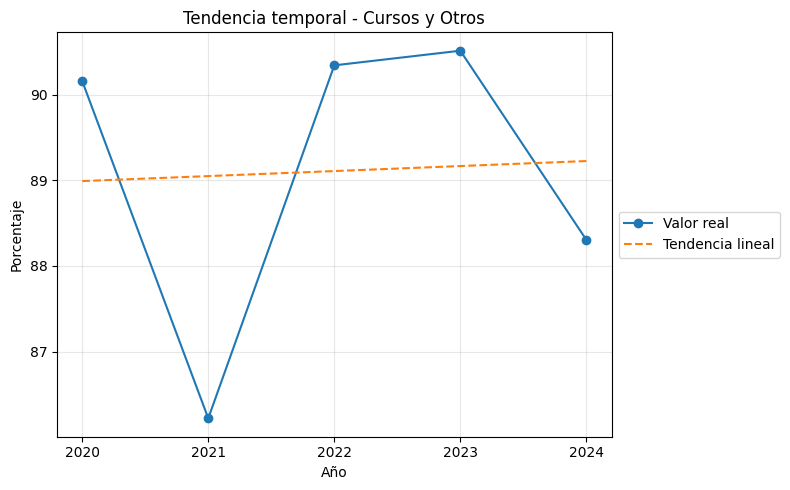


Variable: Solo Otros
Pendiente anual: 0.0977
Intercepto: -196.2830
R²: 0.0844


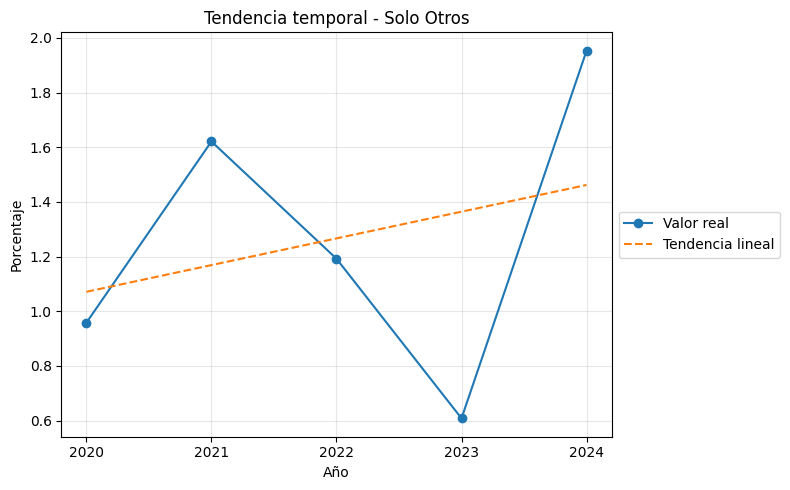

In [27]:
for col in ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]:
    tendencia_lineal(tabla_matriz, col)

In [28]:
resultados_tendencia = []

for col in ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]:
    X = tabla_matriz[["Año"]]
    y = tabla_matriz[col]

    modelo = LinearRegression()
    modelo.fit(X, y)

    resultados_tendencia.append({
        "indicador": col,
        "pendiente_anual": modelo.coef_[0],
        "intercepto": modelo.intercept_,
        "r2": modelo.score(X, y)
    })

resumen_tendencias = pd.DataFrame(resultados_tendencia)
print(resumen_tendencias.round(4))

              indicador  pendiente_anual  intercepto      r2
0          No Formación          -0.4055    821.3230  0.7397
1  Sí Formación (Total)           0.4055   -721.3230  0.7397
2           Solo Cursos          -0.1564    325.8656  0.0275
3        Cursos y Otros           0.0586    -29.3806  0.0025
4            Solo Otros           0.0977   -196.2830  0.0844


<span style="font-size:16px; color: red">**Interpretación rápida**</span>

   - <span style="font-size:14px"> Si la pendiente es positiva, la variable tiende a subir con los años.</span>

   - <span style="font-size:14px"> Si la pendiente es negativa, tiende a bajar.

   - <span style="font-size:14px"> Si el R² es alto, la recta describe bastante bien la trayectoria observada.

   - <span style="font-size:14px"> Si el R² es bajo, la serie fluctúa más y la tendencia lineal representa peor los datos

# <span style="font-size:22px; color: orange">**4. Análisis de SECTOR**</span>

In [29]:
medios_sector

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
84,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Industria,TOTAL,100.000
85,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Construcción,TOTAL,100.000
86,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Comercio y reparación de vehículos,TOTAL,100.000
87,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Transporte y almacenamiento,TOTAL,100.000
88,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Hostelería,TOTAL,100.000
...,...,...,...,...,...,...,...
8026,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,Hostelería,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,39.265
8027,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,"Información, comunicaciones, actividades finan...",EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,19.456
8028,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,"Actividades profesionales, científicas y técnicas",EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,18.212
8029,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,Actividades administrativas y servicios auxili...,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,25.739


In [30]:
medios_sector.groupby('categoria').count().sort_values(by='categoria', ascending=False)

,anio,tabla,pregunta,ambito,variable,porcentaje
categoria,,,,,,
Transporte y almacenamiento,30,30,30,30,30,30
"Información, comunicaciones, actividades financieras, de seguros e inmobiliarias",30,30,30,30,30,30
Industria,30,30,30,30,30,30
Hostelería,30,30,30,30,30,30
Construcción,30,30,30,30,30,30
Comercio y reparación de vehículos,30,30,30,30,30,30
"Actividades profesionales, científicas y técnicas",30,30,30,30,30,30
"Actividades artísticas, recreativas y de entretenimiento y otros servicios",30,30,30,30,30,30
Actividades administrativas y servicios auxiliares,30,30,30,30,30,30


## <span style="font-size:18px; color: orange">**4.1 Agrupamos sector servicios**</span>

<span style="font-size:14px">Agrupamos todos aquellos servicios que no sean `Transporte y almacenamiento` en `Otros servicios` para poder comparar nuestro campo versus los otros del mismo sector. Industria y construcción se mantienen independientes.</span>

In [31]:
def agrupar_sector(cat):
    cat = str(cat).strip().upper()
    
    if cat == "TRANSPORTE Y ALMACENAMIENTO":
        return "Transporte y almacenamiento"
    elif cat == "INDUSTRIA":
        return "Industria"
    elif cat == "CONSTRUCCIÓN":
        return "Construcción"
    else:
        return "Otros Servicios"

In [32]:
medios_sector["sector_agregado"] = medios_sector["categoria"].apply(agrupar_sector)
medios_sector.groupby("sector_agregado").count().sort_values(by="sector_agregado", ascending=False)

C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\1921211039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medios_sector["sector_agregado"] = medios_sector["categoria"].apply(agrupar_sector)


,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
sector_agregado,,,,,,,
Transporte y almacenamiento,30,30,30,30,30,30,30
Otros Servicios,180,180,180,180,180,180,180
Industria,30,30,30,30,30,30,30
Construcción,30,30,30,30,30,30,30


## <span style="font-size:18px; color: orange">**4.2 Clasificamos los medios**</span>

In [33]:
medios_sector["categoria_analitica"] = medios_sector["variable"].apply(clasificar_categoria)
medios_sector

C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\2781228844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medios_sector["categoria_analitica"] = medios_sector["variable"].apply(clasificar_categoria)


,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,sector_agregado,categoria_analitica
84,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Industria,TOTAL,100.000,Industria,total_anual
85,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Construcción,TOTAL,100.000,Construcción,total_anual
86,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Comercio y reparación de vehículos,TOTAL,100.000,Otros Servicios,total_anual
87,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Transporte y almacenamiento,TOTAL,100.000,Transporte y almacenamiento,total_anual
88,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Hostelería,TOTAL,100.000,Otros Servicios,total_anual
...,...,...,...,...,...,...,...,...,...
8026,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,Hostelería,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,39.265,Otros Servicios,no_formacion
8027,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,"Información, comunicaciones, actividades finan...",EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,19.456,Otros Servicios,no_formacion
8028,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,"Actividades profesionales, científicas y técnicas",EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,18.212,Otros Servicios,no_formacion
8029,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,Actividades administrativas y servicios auxili...,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,25.739,Otros Servicios,no_formacion


## <span style="font-size:18px; color: orange">**4.3 Filtramos por las categorías que vamos a analizar**</span>

<span style="font-size:14px">Aprovechamos y cambiamos el nombre de las categorías.</span>

In [34]:
cats_validas = [
    "total_anual",
    "si_formacion_total",
    "no_formacion",
    "cursos_y_otros",
    "solo_cursos",
    "solo_otros"
]

df_sector_analisis = medios_sector.loc[
    medios_sector["categoria_analitica"].isin(cats_validas)
].copy()

df_sector_analisis["categoria_analitica"] = df_sector_analisis["categoria_analitica"].replace({
    "total_anual": "Total Anual",
    "si_formacion_total": "Sí Formación (Total)",
    "no_formacion": "No Formación",
    "cursos_y_otros": "Cursos y Otros",
    "solo_cursos": "Solo Cursos",
    "solo_otros": "Solo Otros"
})

In [35]:
df_sector_analisis.groupby('categoria_analitica').count().sort_values(by='categoria_analitica', ascending=False)

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,sector_agregado
categoria_analitica,,,,,,,,
Total Anual,45,45,45,45,45,45,45,45
Sí Formación (Total),45,45,45,45,45,45,45,45
Solo Otros,45,45,45,45,45,45,45,45
Solo Cursos,45,45,45,45,45,45,45,45
No Formación,45,45,45,45,45,45,45,45
Cursos y Otros,45,45,45,45,45,45,45,45


## <span style="font-size:18px; color: orange">**4.4 Matriz por año y sector agregado**</span>

<span style="font-size:14px; color: red">**Nota:**</span> <span style="font-size:14px">Usamos <code>aggfunc="mean"</code> porque al agrupar varios sectores dentro de **Otros Servicios** necesitábamos una agregación. Como estamos trabajando con porcentajes agregados de sectores distintos, esa agrupación debe interpretarse como un promedio descriptivo entre sectores agrupados, no como un total poblacional.</span>

In [36]:
tabla_sector_agregado = (
    df_sector_analisis
    .pivot_table(
        index=["anio", "sector_agregado"],
        columns="categoria_analitica",
        values="porcentaje",
        aggfunc="mean"
    )
    .reset_index()
    .rename(columns={"anio": "Año"})
)

tabla_sector_agregado.head()

categoria_analitica,Año,sector_agregado,Cursos y Otros,No Formación,Solo Cursos,Solo Otros,Sí Formación (Total),Total Anual
0,2020,Construcción,64.279000,36.544000,25.044,10.677000,63.456000,100.0
1,2020,Industria,64.553000,35.293000,22.506,12.941000,64.707000,100.0
2,2020,Otros Servicios,62.576333,38.483833,22.347,15.076833,61.516167,100.0
3,2020,Transporte y almacenamiento,66.108000,31.821000,26.779,7.113000,68.179000,100.0
4,2021,Construcción,50.595000,29.372000,35.352,14.053000,70.628000,100.0


In [37]:
#Reindexamos
tabla_sector_agregado = tabla_sector_agregado.reindex(columns=["sector_agregado","Año",
                                             "No Formación",
                                             "Sí Formación (Total)",
                                             "Solo Cursos",
                                             "Cursos y Otros",
                                             "Solo Otros",
                                             "Total Anual"])

tabla_sector_agregado.head()

categoria_analitica,sector_agregado,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
0,Construcción,2020,36.544000,63.456000,25.044,64.279000,10.677000,100.0
1,Industria,2020,35.293000,64.707000,22.506,64.553000,12.941000,100.0
2,Otros Servicios,2020,38.483833,61.516167,22.347,62.576333,15.076833,100.0
3,Transporte y almacenamiento,2020,31.821000,68.179000,26.779,66.108000,7.113000,100.0
4,Construcción,2021,29.372000,70.628000,35.352,50.595000,14.053000,100.0


In [38]:
tabla_sector_agregado

categoria_analitica,sector_agregado,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
0,Construcción,2020,36.544000,63.456000,25.044000,64.279000,10.677000,100.0
1,Industria,2020,35.293000,64.707000,22.506000,64.553000,12.941000,100.0
2,Otros Servicios,2020,38.483833,61.516167,22.347000,62.576333,15.076833,100.0
3,Transporte y almacenamiento,2020,31.821000,68.179000,26.779000,66.108000,7.113000,100.0
4,Construcción,2021,29.372000,70.628000,35.352000,50.595000,14.053000,100.0
5,Industria,2021,27.948000,72.052000,24.768000,58.716000,16.516000,100.0
6,Otros Servicios,2021,32.559500,67.440500,25.561500,58.409667,16.028667,100.0
7,Transporte y almacenamiento,2021,27.013000,72.987000,34.678000,49.706000,15.616000,100.0
8,Construcción,2022,24.236000,75.764000,26.951000,58.659000,14.390000,100.0
9,Industria,2022,27.008000,72.992000,20.965000,66.717000,12.319000,100.0


## <span style="font-size:18px; color: orange">**4.5 Variación interanual**</span>

<span style="font-size:14px; color: rgb(186, 229, 116)">**Variación absoluta** en puntos porcentuales (pp) y **variación relativa** en porcentaje (%) de cada categoría respecto al año anterior. Esto nos permite ver cómo evolucionan las diferentes categorías de un año a otro y detectar tendencias.</span>

In [39]:
tabla_yoy_sector = tabla_sector_agregado.sort_values(["sector_agregado",
                                                      "Año"]).copy()

cols = [
    "No Formación",
    "Sí Formación (Total)",
    "Solo Cursos",
    "Cursos y Otros",
    "Solo Otros"
]

for col in cols:
    tabla_yoy_sector[f"{col}_diff_pp"] = (
        tabla_yoy_sector.groupby("sector_agregado")[col].diff()
    )
    
    tabla_yoy_sector[f"{col}_var_relativa_pct"] = (
        tabla_yoy_sector.groupby("sector_agregado"
                                 )[col].pct_change() * 100
    )

tabla_yoy_sector.round(3)

categoria_analitica,sector_agregado,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,No Formación_diff_pp,No Formación_var_relativa_pct,Sí Formación (Total)_diff_pp,Sí Formación (Total)_var_relativa_pct,Solo Cursos_diff_pp,Solo Cursos_var_relativa_pct,Cursos y Otros_diff_pp,Cursos y Otros_var_relativa_pct,Solo Otros_diff_pp,Solo Otros_var_relativa_pct
0,Construcción,2020,36.544,63.456,25.044,64.279,10.677,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Construcción,2021,29.372,70.628,35.352,50.595,14.053,100.0,-7.172,-19.626,7.172,11.302,10.308,41.160,-13.684,-21.288,3.376,31.619
8,Construcción,2022,24.236,75.764,26.951,58.659,14.390,100.0,-5.136,-17.486,5.136,7.272,-8.401,-23.764,8.064,15.938,0.337,2.398
12,Construcción,2023,20.604,79.396,26.216,61.345,12.439,100.0,-3.632,-14.986,3.632,4.794,-0.735,-2.727,2.686,4.579,-1.951,-13.558
16,Construcción,2024,22.287,77.713,29.467,61.593,8.940,100.0,1.683,8.168,-1.683,-2.120,3.251,12.401,0.248,0.404,-3.499,-28.129
1,Industria,2020,35.293,64.707,22.506,64.553,12.941,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Industria,2021,27.948,72.052,24.768,58.716,16.516,100.0,-7.345,-20.811,7.345,11.351,2.262,10.051,-5.837,-9.042,3.575,27.625
9,Industria,2022,27.008,72.992,20.965,66.717,12.319,100.0,-0.940,-3.363,0.940,1.305,-3.803,-15.354,8.001,13.627,-4.197,-25.412
13,Industria,2023,21.644,78.356,24.289,60.451,15.260,100.0,-5.364,-19.861,5.364,7.349,3.324,15.855,-6.266,-9.392,2.941,23.874
17,Industria,2024,23.778,76.222,20.911,64.223,14.866,100.0,2.134,9.860,-2.134,-2.723,-3.378,-13.908,3.772,6.240,-0.394,-2.582


<span style="font-size:14px">En el caso de la **variación absoluta** si una variable (medio) da 10 o -5 significa que creció un 10% respecto el año anterior o disminuyó un 5% respectivamente. En cambio, en la **variación relativa** la interpretación debe ser mucho más cuidadosa, ya que refleja el cambio porcentual relativo al valor del año anterior.</span>

<span style="font-size:14px; color: red">**¿Cómo interpretar la variación relativa?:**</span> <span style="font-size:14px">Si un valor nos pasa de 20 a 25, la variación relativa sería ((25-20)/20)*100 = 25%. En cambio, si un valor pasa de 70 a 75, la variación relativa sería ((75-70)/70)*100 ≈ 7.14%. Ambos cambian 5 puntos pero la interpretación es diferente debido al valor base.</span>

## <span style="font-size:18px; color: orange">**4.6 Visualizaciones**</span>

### <span style="font-size:14px; color: rgb(92, 234, 186)">**4.6.0 Evolución de las modalidades de formación por sector**</span> 

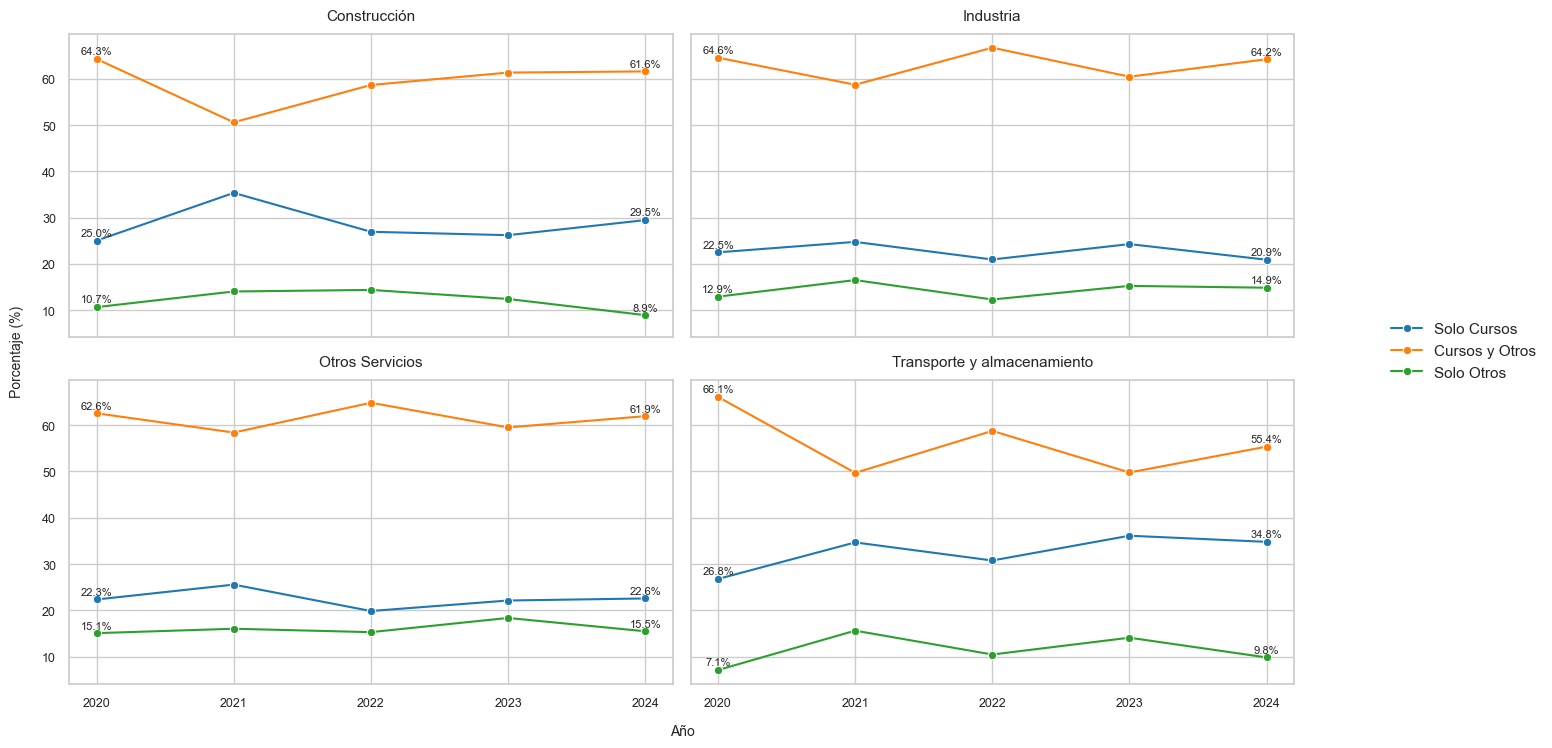

In [115]:
# 1. Configurar el estilo base
sns.set_theme(style="whitegrid")

# 2. Definir los tres colores exactos que usaste antes para las líneas
colores_exactos = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# 3. Crear el panel 2x2 transparente
fig, axes = plt.subplots(
    2, 2, figsize=(14, 8), sharex=True, sharey=True, facecolor="none"
)

# Lista de sectores (deben coincidir exactamente con los nombres en 'sector_agregado')
sectores = [
    "Construcción",
    "Industria",
    "Otros Servicios",
    "Transporte y almacenamiento",
]
columnas_formacion = ["Solo Cursos", "Cursos y Otros", "Solo Otros"]

# 4. Iterar sobre cada gráfico y sector
for ax, sector in zip(axes.flat, sectores):
    # Forzar fondo transparente en la cuadrícula de este subgráfico
    ax.set_facecolor("none")

    # Filtrar el DataFrame para el sector actual
    df_sector = tabla_yoy_sector[
        tabla_yoy_sector["sector_agregado"] == sector
    ]

    # Graficar cada una de las 3 líneas con su color correspondiente
    for col, color in zip(columnas_formacion, colores_exactos):
        sns.lineplot(
            data=df_sector,
            x="Año",
            y=col,
            ax=ax,
            marker="o",
            color=color,
            label=col,
        )

        # Añadir etiquetas de datos en el primer (2020) y último año (2024)
        for _, fila in df_sector[df_sector["Año"].isin([2020, 2024])].iterrows():
            ax.text(
                x=fila["Año"],
                y=fila[col] + 1,  # Desplazamiento vertical para que no pise el punto
                s=f"{fila[col]:.1f}%",
                fontsize=8,
                ha="center",
            )

    # Personalización individual limpia
    ax.set_title(sector, fontsize=11, pad=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.set_xticks([2020, 2021, 2022, 2023, 2024])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.get_legend().remove()  # Quitamos la leyenda individual de cada gráfico

# 5. Configurar etiquetas de los ejes globales
fig.text(0.5, 0.02, "Año", ha="center", fontsize=10)
fig.text(
    0.02, 0.5, "Porcentaje (%)", va="center", rotation="vertical", fontsize=10
)

# 6. Crear una única leyenda global con fondo transparente a la derecha
handles, labels = ax.get_legend_handles_labels()
legend = fig.legend(
    handles[:3],
    labels[:3],
    loc="center right",
    bbox_to_anchor=(1.12, 0.5),
    frameon=True,
)
legend.get_frame().set_facecolor("none")  # Quita el fondo blanco de la leyenda
legend.get_frame().set_linewidth(0)  # Elimina el borde gris de la leyenda

plt.tight_layout(rect=[0.03, 0.03, 0.95, 0.95])
plt.show()


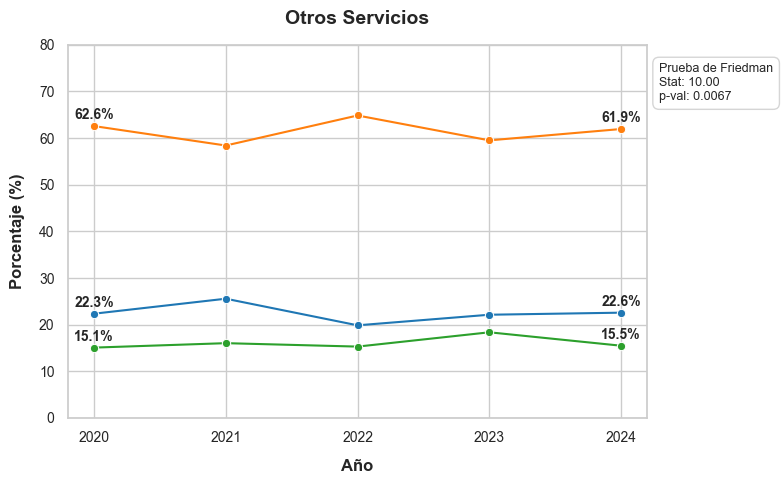

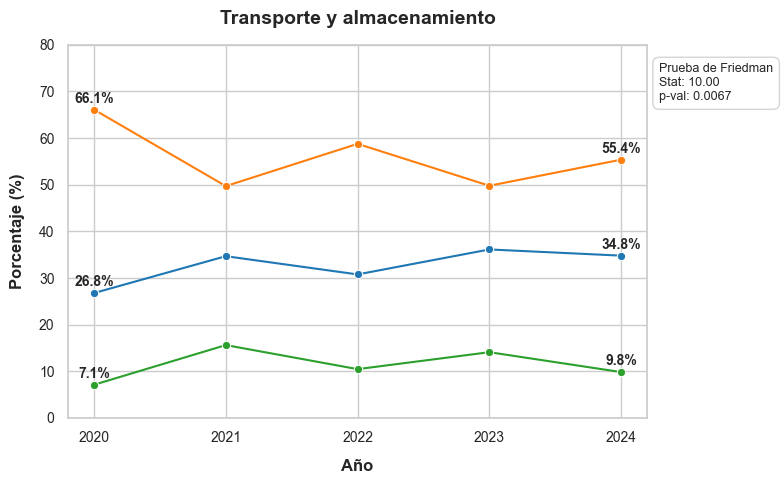

In [198]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# 1. Configurar el estilo base
sns.set_theme(style="whitegrid")

# 2. Definir los tres colores exactos para las líneas
colores_exactos = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Lista de sectores (generará un gráfico independiente por cada uno)
sectores = [
    "Otros Servicios",
    "Transporte y almacenamiento",
]
columnas_formacion = ["Solo Cursos", "Cursos y Otros", "Solo Otros"]

# 3. Iterar para crear cada gráfico por separado
for sector in sectores:
    # Crear una nueva figura independiente con fondo transparente
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="none")
    ax.set_facecolor("none")

    # Filtrar el DataFrame para el sector actual
    df_sector = tabla_yoy_sector[
        tabla_yoy_sector["sector_agregado"] == sector
    ].sort_values("Año")

    # Graficar cada una de las 3 líneas con su color correspondiente
    for col, color in zip(columnas_formacion, colores_exactos):
        sns.lineplot(
            data=df_sector,
            x="Año",
            y=col,
            ax=ax,
            marker="o",
            color=color,
            legend=False,
        )

        # CORREGIDO: Se reincorporan los años [2020, 2024] dentro de .isin()
        for _, fila in df_sector[df_sector["Año"].isin([2020, 2024])].iterrows():
            ax.text(
                x=fila["Año"],
                y=fila[col] + 1.5,
                s=f"{fila[col]:.1f}%",
                fontsize=10,
                ha="center",
                fontweight="bold",
            )

    # CORREGIDO: Pasar cada columna como un vector independiente a la prueba de Friedman
    try:
        stat_val, p_val = stats.friedmanchisquare(
            df_sector[columnas_formacion[0]],
            df_sector[columnas_formacion[1]],
            df_sector[columnas_formacion[2]],
        )
        texto_estadistico = (
            f"Prueba de Friedman\nStat: {stat_val:.2f}\np-val: {p_val:.4f}"
        )
    except Exception:
        # Alternativa ANOVA si ocurre algún error con el test anterior
        stat_val, p_val = stats.f_oneway(
            df_sector[columnas_formacion[0]],
            df_sector[columnas_formacion[1]],
            df_sector[columnas_formacion[2]],
        )
        texto_estadistico = f"ANOVA de una vía\nF-stat: {stat_val:.2f}\np-val: {p_val:.4f}"

    # Insertar el recuadro estadístico en la esquina superior derecha exterior
    ax.text(
        x=1.02,
        y=0.95,
        s=texto_estadistico,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            alpha=0.8,
            edgecolor="#cccccc",
        ),
    )

    # Forzar que el eje Y empiece en 0 y llegue a 80
    ax.set_ylim(0, 80)

    # Personalización limpia de los ejes individuales
    ax.set_title(sector, fontsize=14, pad=15, fontweight="bold")
    ax.tick_params(axis="both", labelsize=10)
    ax.set_xticks([2020, 2021, 2022, 2023, 2024])

    # Añadir etiquetas directamente a los ejes de esta gráfica
    ax.set_xlabel("Año", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_ylabel(
        "Porcentaje (%)", fontsize=12, fontweight="bold", labelpad=10
    )

    # Ajustar el diseño y mostrar la figura actual antes de pasar a la siguiente
    plt.tight_layout()
    plt.show()



### <span style="font-size:14px; color: rgb(92, 234, 186)">**4.6.1 Comparativa de Sí Formación (Total)**</span> 

   - <span style="font-size:14px">*Comparamos como varia el porcentaje de "Sí Formación (Total)" entre los diferentes sectores agregados a lo largo de los años.*</span>

<span style="font-size:14px; color: red">**Observación:**</span> <span style="font-size:14px">Tal vez estamos sesgando más la representación de los 'Otros Servicios' porqué al haber agregado varios subsectores, la variabilidad interna se pierde. Así que tal vez un mejor planteamiento analítico sería mantenerlos desagregados.</span>

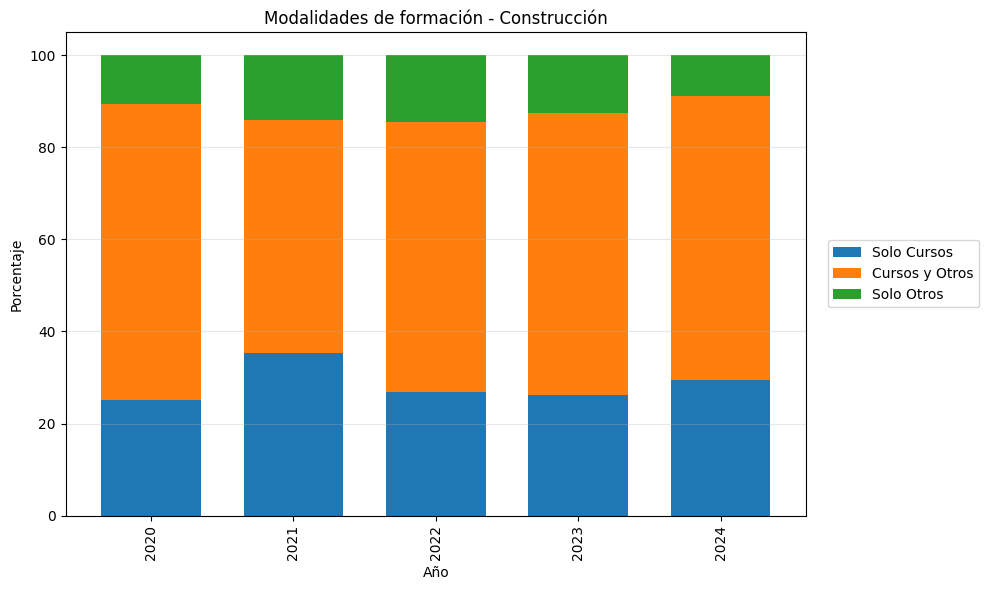

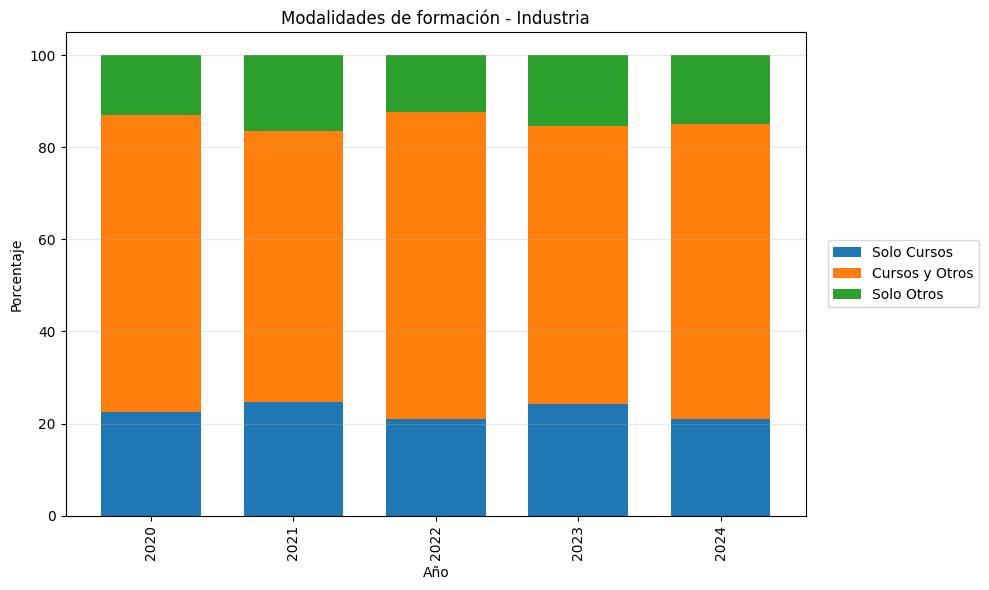

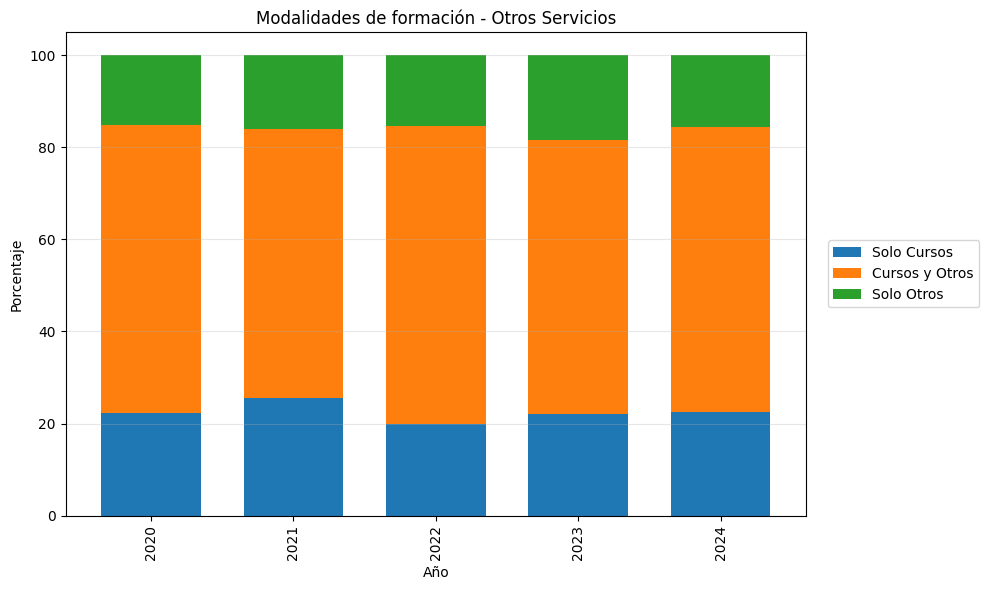

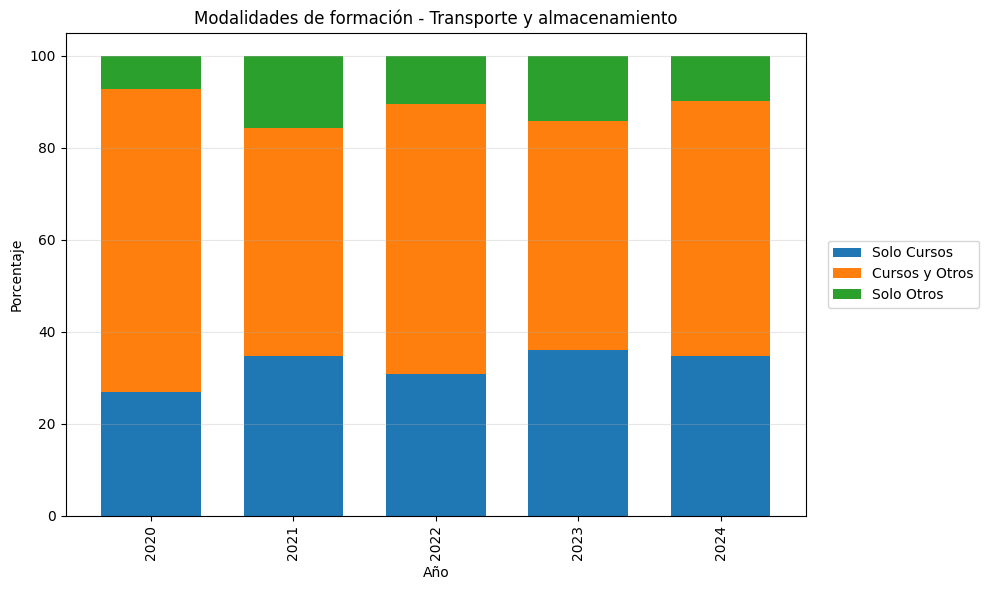

In [40]:
sectores = tabla_sector_agregado["sector_agregado"].unique()

for sector in sectores:
    temp = tabla_sector_agregado[
        tabla_sector_agregado["sector_agregado"] == sector
    ].sort_values("Año").copy()

    temp_plot = temp[["Año", "Solo Cursos", "Cursos y Otros", "Solo Otros"]].copy()
    temp_plot["Año"] = temp_plot["Año"].astype(int)
    temp_plot = temp_plot.set_index("Año")

    ax = temp_plot.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        width=0.7
    )

    ax.set_title(f"Modalidades de formación - {sector}")
    ax.set_xlabel("Año")
    ax.set_ylabel("Porcentaje")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

### <span style="font-size:14px; color: rgb(92, 234, 186)">**4.6.2 Medios dentro de Transporte y Almacenamiento**</span> 

In [41]:
temp

categoria_analitica,sector_agregado,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
3,Transporte y almacenamiento,2020,31.821,68.179,26.779,66.108,7.113,100.0
7,Transporte y almacenamiento,2021,27.013,72.987,34.678,49.706,15.616,100.0
11,Transporte y almacenamiento,2022,23.381,76.619,30.769,58.770,10.460,100.0
15,Transporte y almacenamiento,2023,20.393,79.607,36.123,49.784,14.093,100.0
19,Transporte y almacenamiento,2024,22.595,77.405,34.796,55.376,9.828,100.0


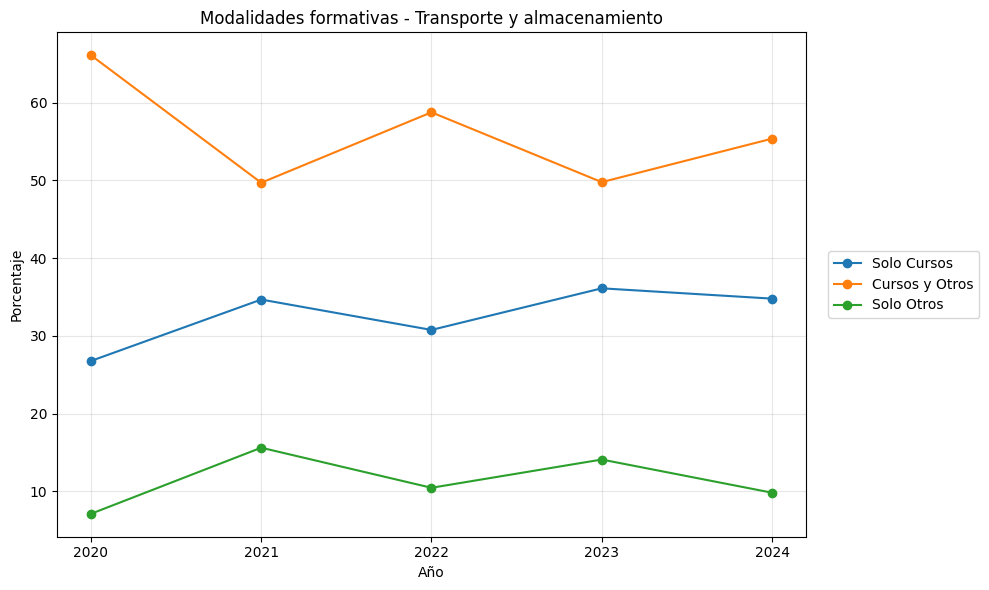

In [42]:
temp = tabla_sector_agregado[
    tabla_sector_agregado["sector_agregado"] == "Transporte y almacenamiento"
].copy()

plt.figure(figsize=(10, 6))
plt.plot(temp["Año"], temp["Solo Cursos"], marker="o", label="Solo Cursos")
plt.plot(temp["Año"], temp["Cursos y Otros"], marker="o", label="Cursos y Otros")
plt.plot(temp["Año"], temp["Solo Otros"], marker="o", label="Solo Otros")

plt.title("Modalidades formativas - Transporte y almacenamiento")
plt.xlabel("Año")
plt.ylabel("Porcentaje")
plt.xticks(temp["Año"].astype(int))
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### <span style="font-size:14px; color: rgb(92, 234, 186)">**4.6.3 Comparación entre Transporte y Almacenamiento versus Otros Servicios**</span> 

In [43]:
df_comp = tabla_sector_agregado[
    tabla_sector_agregado["sector_agregado"].isin([
        "Transporte y almacenamiento",
        "Otros Servicios"
    ])
].copy()

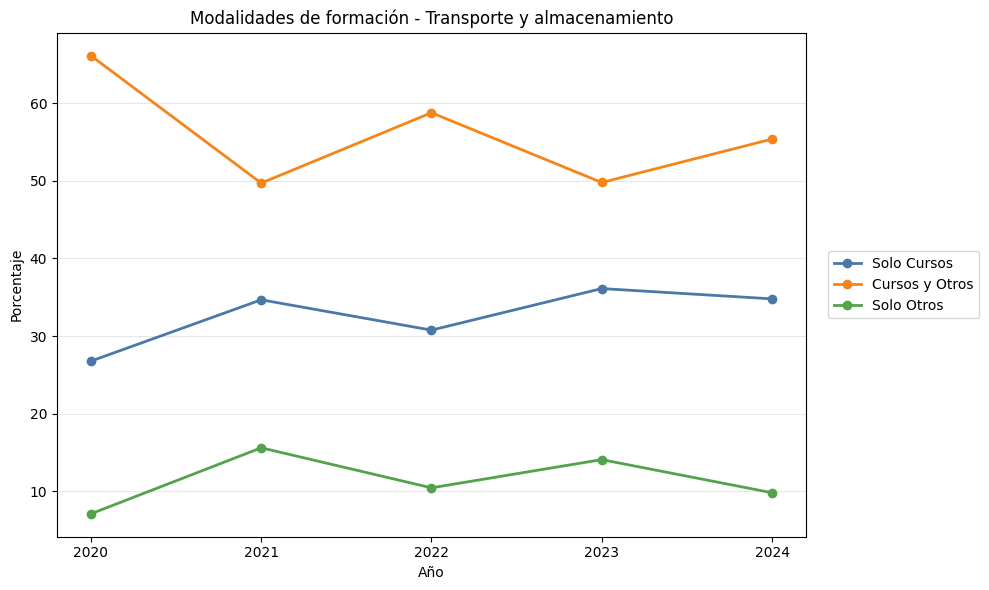

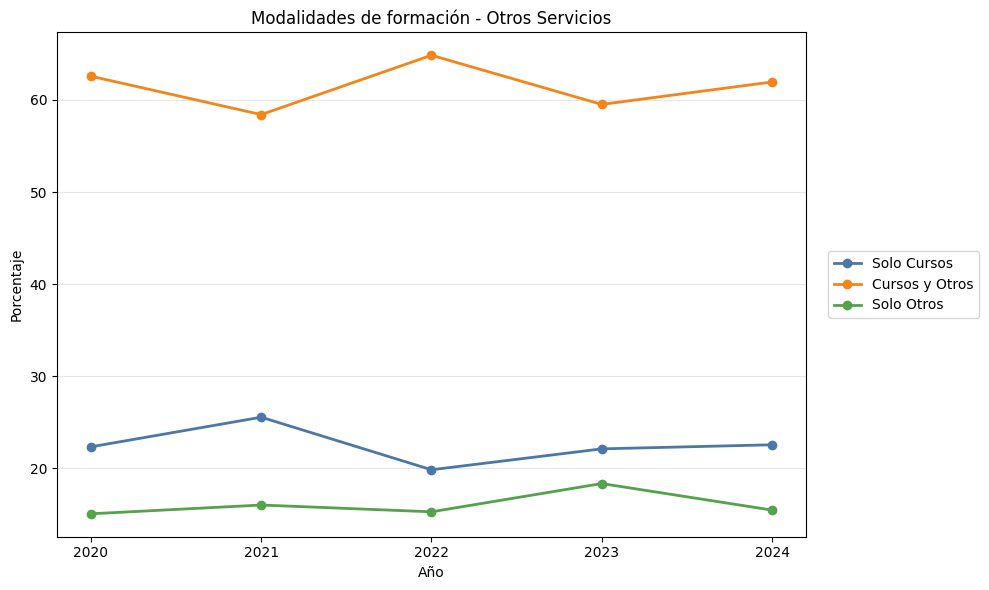

In [44]:
for grupo in ["Transporte y almacenamiento", "Otros Servicios"]:
    temp = df_comp[df_comp["sector_agregado"] == grupo].sort_values("Año").copy()

    temp_plot = temp[["Año", "Solo Cursos", "Cursos y Otros", "Solo Otros"]].copy()
    temp_plot["Año"] = temp_plot["Año"].astype(int)
    temp_plot = temp_plot.set_index("Año")

    ax = temp_plot.plot(
        kind="line",
        figsize=(10, 6),
        marker="o",
        linewidth=2,
        color=["#4C78A8", "#F58518", "#54A24B"]
    )

    ax.set_title(f"Modalidades de formación - {grupo}")
    ax.set_xlabel("Año")
    ax.set_ylabel("Porcentaje")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(axis="y", alpha=0.3)
    
    plt.xticks(temp["Año"].astype(int))
    plt.tight_layout()
    plt.show()

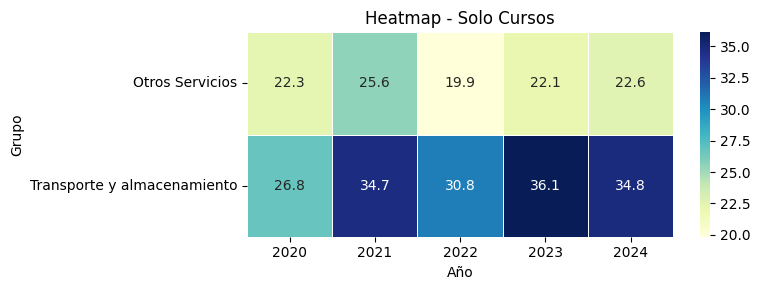

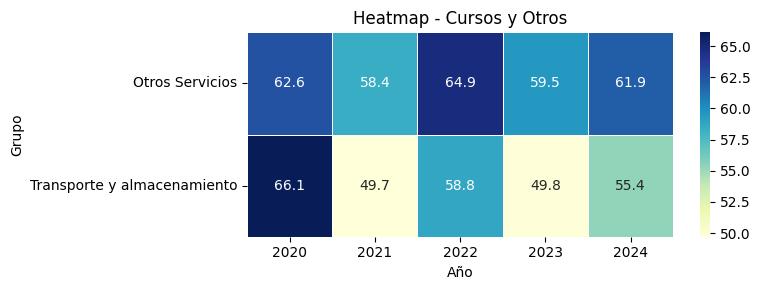

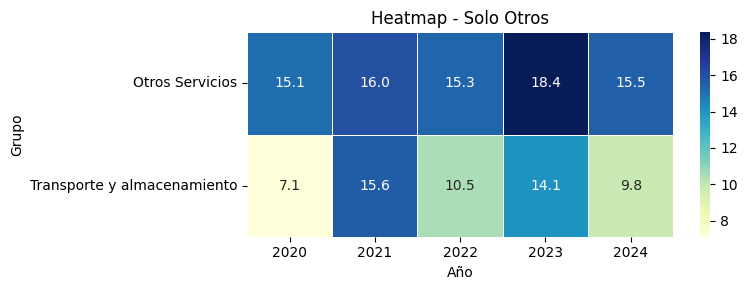

In [45]:
metodos = ["Solo Cursos", "Cursos y Otros", "Solo Otros"]

for metodo in metodos:
    pivot_temp = df_comp.pivot_table(
        index="sector_agregado",
        columns="Año",
        values=metodo
    )

    plt.figure(figsize=(8, 3))
    sns.heatmap(
        pivot_temp,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5
    )
    plt.title(f"Heatmap - {metodo}")
    plt.xlabel("Año")
    plt.ylabel("Grupo")
    plt.tight_layout()
    plt.show()

<span style="font-size:14px; color: red">**OJO:**</span> <span style="font-size:14px">Esta comparación puede estar sesgada debido a la agregación de subsectores en 'Otros Servicios'.</span>

### <span style="font-size:14px; color: rgb(92, 234, 186)">**4.6.4 Heatmap por sector y años**</span> 

<span style="font-size:14px">Los % son los valores de cada modalidad de formación en relación al total de formación en ese sector y año.</span>

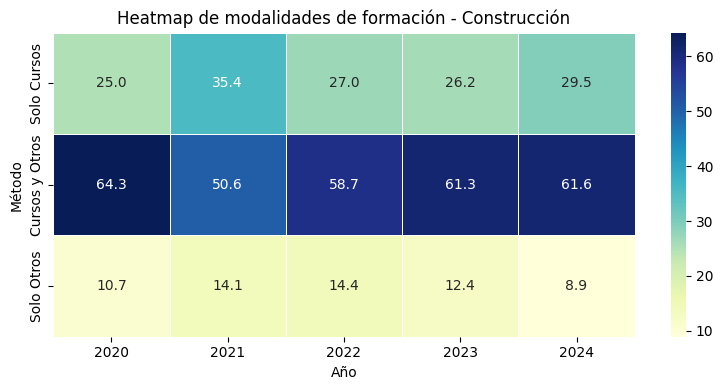

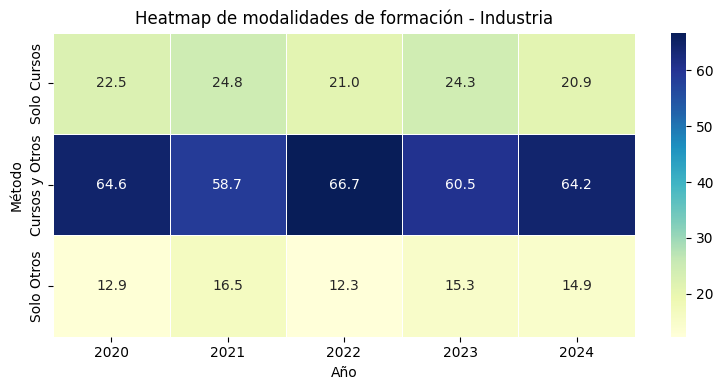

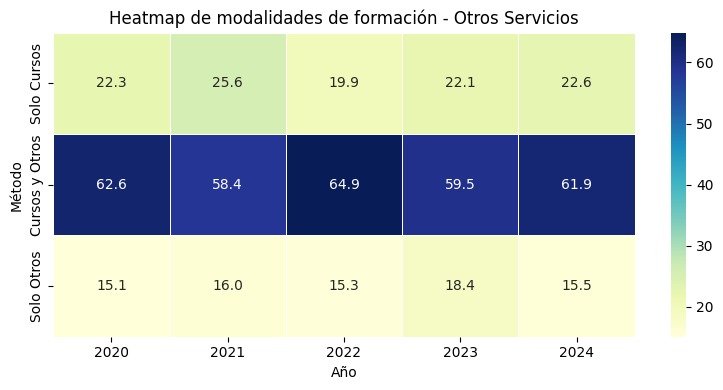

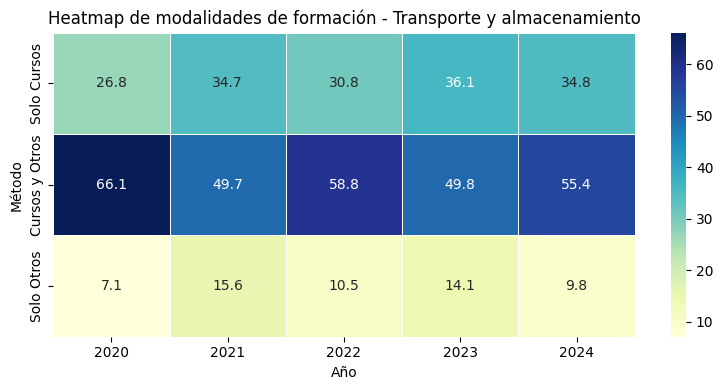

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

metodos = ["Solo Cursos", "Cursos y Otros", "Solo Otros"]

for sector in sectores:
    temp = tabla_sector_agregado[
        tabla_sector_agregado["sector_agregado"] == sector
    ].sort_values("Año").copy()

    heatmap_data = temp.set_index("Año")[metodos].T

    plt.figure(figsize=(8, 4))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5
    )

    plt.title(f"Heatmap de modalidades de formación - {sector}")
    plt.xlabel("Año")
    plt.ylabel("Método")
    plt.tight_layout()
    plt.show()

## <span style="font-size:18px; color: orange">**4.7 Estadísticas por sector y años**</span>

### <span style="font-size:16px; color: orange">**4.7.1 Wilcoxon pareado**</span>

In [ ]:
transporte = tabla_sector_agregado[
    tabla_sector_agregado["sector_agregado"] == "Transporte y almacenamiento"
].sort_values("Año")

otros = tabla_sector_agregado[
    tabla_sector_agregado["sector_agregado"] == "Otros Servicios"
].sort_values("Año")

stat, p = wilcoxon(
    transporte["Solo Cursos"],
    otros["Solo Cursos"]
)

print("Estadístico Wilcoxon:", stat)
print("p-valor:", p)

Estadístico Wilcoxon: 0.0
p-valor: 0.0625


In [ ]:
metodos = ["Solo Cursos", "Cursos y Otros", "Solo Otros"]

for metodo in metodos:
    stat, p = wilcoxon(
        transporte[metodo],
        otros[metodo]
    )
    print(f"{metodo} -> estadístico: {stat}, p-valor: {p}")

Solo Cursos -> estadístico: 0.0, p-valor: 0.0625
Cursos y Otros -> estadístico: 1.0, p-valor: 0.125
Solo Otros -> estadístico: 0.0, p-valor: 0.0625


In [ ]:
resultados_wilcoxon = []

for metodo in ["Solo Cursos", "Cursos y Otros", "Solo Otros"]:
    stat, p = wilcoxon(transporte[metodo], otros[metodo])
    resultados_wilcoxon.append({
        "metodo": metodo,
        "estadistico": stat,
        "p_valor": p
    })

resumen_wilcoxon = pd.DataFrame(resultados_wilcoxon)
print(resumen_wilcoxon)

           metodo  estadistico  p_valor
0     Solo Cursos          0.0   0.0625
1  Cursos y Otros          1.0   0.1250
2      Solo Otros          0.0   0.0625


# <span style="font-size:30px; color: orange">**MEDIOS COMUNIDAD AUTÓNOMA**</span>

In [66]:
medios_comunidad_autonoma

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
93,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Andalucía,TOTAL,100.000
94,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Aragón,TOTAL,100.000
95,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Asturias (Principado de),TOTAL,100.000
96,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Balears (Illes),TOTAL,100.000
97,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Canarias,TOTAL,100.000
...,...,...,...,...,...,...,...
8043,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Madrid (Comunidad de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,27.009
8044,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Murcia (Región de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,23.066
8045,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Navarra (Comunidad Foral de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,21.157
8046,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,País Vasco,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,28.829


In [67]:
medios_comunidad_autonoma.groupby('categoria').count().sort_values(by='categoria', ascending=False)

,anio,tabla,pregunta,ambito,variable,porcentaje
categoria,,,,,,
"Rioja, La",30,30,30,30,30,30
País Vasco,30,30,30,30,30,30
Navarra (Comunidad Foral de),30,30,30,30,30,30
Murcia (Región de),30,30,30,30,30,30
Madrid (Comunidad de),30,30,30,30,30,30
Galicia,30,30,30,30,30,30
Extremadura,30,30,30,30,30,30
Comunitat Valenciana,30,30,30,30,30,30
Cataluña,30,30,30,30,30,30


## <span style="font-size:18px; color: orange">**4.2 Clasificamos los medios**</span>

In [68]:
medios_comunidad_autonoma["categoria_analitica"] = medios_comunidad_autonoma["variable"].apply(clasificar_categoria)
medios_comunidad_autonoma

C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\3310780977.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medios_comunidad_autonoma["categoria_analitica"] = medios_comunidad_autonoma["variable"].apply(clasificar_categoria)


,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,categoria_analitica
93,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Andalucía,TOTAL,100.000,total_anual
94,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Aragón,TOTAL,100.000,total_anual
95,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Asturias (Principado de),TOTAL,100.000,total_anual
96,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Balears (Illes),TOTAL,100.000,total_anual
97,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Canarias,TOTAL,100.000,total_anual
...,...,...,...,...,...,...,...,...
8043,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Madrid (Comunidad de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,27.009,no_formacion
8044,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Murcia (Región de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,23.066,no_formacion
8045,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Navarra (Comunidad Foral de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,21.157,no_formacion
8046,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,País Vasco,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,28.829,no_formacion


## <span style="font-size:18px; color: orange">**4.3 Filtramos por las categorías que vamos a analizar**</span>

<span style="font-size:14px">Aprovechamos y cambiamos el nombre de las categorías.</span>

In [70]:
cats_validas = [
    "total_anual",
    "si_formacion_total",
    "no_formacion",
    "cursos_y_otros",
    "solo_cursos",
    "solo_otros"
]

df_ccaa_analisis = medios_comunidad_autonoma.loc[
    medios_comunidad_autonoma["categoria_analitica"].isin(cats_validas)
].copy()

df_ccaa_analisis["categoria_analitica"] = df_ccaa_analisis["categoria_analitica"].replace({
    "total_anual": "Total Anual",
    "si_formacion_total": "Sí Formación (Total)",
    "no_formacion": "No Formación",
    "cursos_y_otros": "Cursos y Otros",
    "solo_cursos": "Solo Cursos",
    "solo_otros": "Solo Otros"
})
df_ccaa_analisis

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,categoria_analitica
93,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Andalucía,TOTAL,100.000,Total Anual
94,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Aragón,TOTAL,100.000,Total Anual
95,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Asturias (Principado de),TOTAL,100.000,Total Anual
96,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Balears (Illes),TOTAL,100.000,Total Anual
97,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",ccaa,Canarias,TOTAL,100.000,Total Anual
...,...,...,...,...,...,...,...,...
8043,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Madrid (Comunidad de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,27.009,No Formación
8044,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Murcia (Región de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,23.066,No Formación
8045,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Navarra (Comunidad Foral de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,21.157,No Formación
8046,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,País Vasco,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,28.829,No Formación


## <span style="font-size:18px; color: orange">**4.4 Matriz por año y sector agregado**</span>

In [71]:
tabla_ccaa_agregado = (
    df_ccaa_analisis
    .pivot_table(
        index=["anio", "categoria"],
        columns="categoria_analitica",
        values="porcentaje",
        aggfunc="mean"
    )
    .reset_index()
    .rename(columns={"anio": "Año", "categoria": "Comunidad Autónoma"})
)

tabla_ccaa_agregado.head()

categoria_analitica,Año,Comunidad Autónoma,Cursos y Otros,No Formación,Solo Cursos,Solo Otros,Sí Formación (Total),Total Anual
0,2020,Andalucía,54.639,33.100,29.919,15.442,66.900,100.0
1,2020,Aragón,61.544,45.004,25.687,12.770,54.996,100.0
2,2020,Asturias (Principado de),60.055,45.369,29.173,10.773,54.631,100.0
3,2020,Balears (Illes),58.050,44.529,29.874,12.076,55.471,100.0
4,2020,Canarias,61.677,44.302,28.426,9.897,55.698,100.0


In [72]:
#Reindexamos
tabla_ccaa_agregado = tabla_ccaa_agregado.reindex(columns=["Comunidad Autónoma","Año",
                                             "No Formación",
                                             "Sí Formación (Total)",
                                             "Solo Cursos",
                                             "Cursos y Otros",
                                             "Solo Otros",
                                             "Total Anual"])

tabla_ccaa_agregado.head()

categoria_analitica,Comunidad Autónoma,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
0,Andalucía,2020,33.100,66.900,29.919,54.639,15.442,100.0
1,Aragón,2020,45.004,54.996,25.687,61.544,12.770,100.0
2,Asturias (Principado de),2020,45.369,54.631,29.173,60.055,10.773,100.0
3,Balears (Illes),2020,44.529,55.471,29.874,58.050,12.076,100.0
4,Canarias,2020,44.302,55.698,28.426,61.677,9.897,100.0


In [118]:
tabla_ccaa_agregado.groupby('Comunidad Autónoma').count().sort_values(by='Comunidad Autónoma', ascending=False)

categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
Comunidad Autónoma,,,,,,,
"Rioja, La",5,5,5,5,5,5,5
País Vasco,5,5,5,5,5,5,5
Navarra (Comunidad Foral de),5,5,5,5,5,5,5
Murcia (Región de),5,5,5,5,5,5,5
Madrid (Comunidad de),5,5,5,5,5,5,5
Galicia,5,5,5,5,5,5,5
Extremadura,5,5,5,5,5,5,5
Comunitat Valenciana,5,5,5,5,5,5,5
Cataluña,5,5,5,5,5,5,5


## <span style="font-size:18px; color: orange">**4.5 Variación interanual**</span>

In [73]:
tabla_yoy_ccaa = tabla_ccaa_agregado.sort_values(["Comunidad Autónoma",
                                                      "Año"]).copy()

cols = [
    "No Formación",
    "Sí Formación (Total)",
    "Solo Cursos",
    "Cursos y Otros",
    "Solo Otros"
]

for col in cols:
    tabla_yoy_ccaa[f"{col}_diff_pp"] = (
        tabla_yoy_ccaa.groupby("Comunidad Autónoma")[col].diff()
    )
    
    tabla_yoy_ccaa[f"{col}_var_relativa_pct"] = (
        tabla_yoy_ccaa.groupby("Comunidad Autónoma"
                                 )[col].pct_change() * 100
    )

tabla_yoy_ccaa.round(3)

categoria_analitica,Comunidad Autónoma,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,No Formación_diff_pp,No Formación_var_relativa_pct,Sí Formación (Total)_diff_pp,Sí Formación (Total)_var_relativa_pct,Solo Cursos_diff_pp,Solo Cursos_var_relativa_pct,Cursos y Otros_diff_pp,Cursos y Otros_var_relativa_pct,Solo Otros_diff_pp,Solo Otros_var_relativa_pct
0,Andalucía,2020,33.100,66.900,29.919,54.639,15.442,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,Andalucía,2021,34.248,65.752,35.684,49.645,14.672,100.0,1.148,3.468,-1.148,-1.716,5.765,19.269,-4.994,-9.140,-0.770,-4.986
34,Andalucía,2022,31.150,68.850,26.707,61.262,12.031,100.0,-3.098,-9.046,3.098,4.712,-8.977,-25.157,11.617,23.400,-2.641,-18.000
51,Andalucía,2023,26.692,73.308,30.521,54.173,15.307,100.0,-4.458,-14.311,4.458,6.475,3.814,14.281,-7.089,-11.572,3.276,27.230
68,Andalucía,2024,26.676,73.324,31.577,53.315,15.109,100.0,-0.016,-0.060,0.016,0.022,1.056,3.460,-0.858,-1.584,-0.198,-1.294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,"Rioja, La",2020,42.068,57.932,22.194,64.935,12.872,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,"Rioja, La",2021,40.113,59.887,23.921,58.560,17.520,100.0,-1.955,-4.647,1.955,3.375,1.727,7.781,-6.375,-9.818,4.648,36.109
50,"Rioja, La",2022,31.217,68.783,19.355,62.297,18.348,100.0,-8.896,-22.177,8.896,14.855,-4.566,-19.088,3.737,6.381,0.828,4.726
67,"Rioja, La",2023,25.576,74.424,23.466,58.000,18.535,100.0,-5.641,-18.070,5.641,8.201,4.111,21.240,-4.297,-6.898,0.187,1.019


In [74]:
tabla_yoy_ccaa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 0 to 84
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Comunidad Autónoma                     85 non-null     object 
 1   Año                                    85 non-null     int64  
 2   No Formación                           85 non-null     float64
 3   Sí Formación (Total)                   85 non-null     float64
 4   Solo Cursos                            85 non-null     float64
 5   Cursos y Otros                         85 non-null     float64
 6   Solo Otros                             85 non-null     float64
 7   Total Anual                            85 non-null     float64
 8   No Formación_diff_pp                   68 non-null     float64
 9   No Formación_var_relativa_pct          68 non-null     float64
 10  Sí Formación (Total)_diff_pp           68 non-null     float64
 11  Sí Formación 

In [119]:
#Como puedo saber si comunidad valenciana esta en mi dataframe?
tabla_yoy_ccaa[tabla_yoy_ccaa["Comunidad Autónoma"].str.contains("Madrid", case=False, na=False)]

categoria_analitica,Comunidad Autónoma,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,No Formación_diff_pp,No Formación_var_relativa_pct,Sí Formación (Total)_diff_pp,Sí Formación (Total)_var_relativa_pct,Solo Cursos_diff_pp,Solo Cursos_var_relativa_pct,Cursos y Otros_diff_pp,Cursos y Otros_var_relativa_pct,Solo Otros_diff_pp,Solo Otros_var_relativa_pct
12,Madrid (Comunidad de),2020,39.947,60.053,22.158,65.001,12.842,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,Madrid (Comunidad de),2021,27.819,72.181,23.929,57.905,18.166,100.0,-12.128,-30.360227,12.128,20.195494,1.771,7.992599,-7.096,-10.916755,5.324,41.457717
46,Madrid (Comunidad de),2022,24.157,75.843,19.310,67.651,13.039,100.0,-3.662,-13.163665,3.662,5.073357,-4.619,-19.302938,9.746,16.831016,-5.127,-28.223054
63,Madrid (Comunidad de),2023,27.091,72.909,18.568,64.412,17.020,100.0,2.934,12.145548,-2.934,-3.868518,-0.742,-3.842569,-3.239,-4.787808,3.981,30.531482
80,Madrid (Comunidad de),2024,27.009,72.991,22.853,62.348,14.799,100.0,-0.082,-0.302684,0.082,0.112469,4.285,23.077337,-2.064,-3.204372,-2.221,-13.049354


<span style="font-size:18px; color: orange">**Filtramos por las comunidades donde tenemos sucursales**</span>

In [ ]:
#filtramos para quedarnos con Madrid, Cataluña, Comunidad Valenciana y Andalucía
comunidades_filtradas = ["Madrid", "Cataluña", "Comunitat Valenciana", "Andalucía", "País Vasco"]
filtrado_ccaa = tabla_yoy_ccaa[tabla_yoy_ccaa["Comunidad Autónoma"].isin(comunidades_filtradas)]
filtrado_ccaa

categoria_analitica,Comunidad Autónoma,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,No Formación_diff_pp,No Formación_var_relativa_pct,Sí Formación (Total)_diff_pp,Sí Formación (Total)_var_relativa_pct,Solo Cursos_diff_pp,Solo Cursos_var_relativa_pct,Cursos y Otros_diff_pp,Cursos y Otros_var_relativa_pct,Solo Otros_diff_pp,Solo Otros_var_relativa_pct
0,Andalucía,2020,33.100,66.900,29.919,54.639,15.442,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,Andalucía,2021,34.248,65.752,35.684,49.645,14.672,100.0,1.148,3.468278,-1.148,-1.715994,5.765,19.268692,-4.994,-9.139992,-0.770,-4.986401
34,Andalucía,2022,31.150,68.850,26.707,61.262,12.031,100.0,-3.098,-9.045784,3.098,4.711644,-8.977,-25.156933,11.617,23.400141,-2.641,-18.000273
51,Andalucía,2023,26.692,73.308,30.521,54.173,15.307,100.0,-4.458,-14.311396,4.458,6.474946,3.814,14.280900,-7.089,-11.571610,3.276,27.229657
68,Andalucía,2024,26.676,73.324,31.577,53.315,15.109,100.0,-0.016,-0.059943,0.016,0.021826,1.056,3.459913,-0.858,-1.583815,-0.198,-1.293526
8,Cataluña,2020,39.428,60.572,19.946,63.386,16.668,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,Cataluña,2021,32.093,67.907,25.019,57.923,17.058,100.0,-7.335,-18.603530,7.335,12.109556,5.073,25.433671,-5.463,-8.618622,0.390,2.339813
42,Cataluña,2022,25.208,74.792,16.877,66.798,16.325,100.0,-6.885,-21.453276,6.885,10.138866,-8.142,-32.543267,8.875,15.322066,-0.733,-4.297104
59,Cataluña,2023,25.518,74.482,19.602,61.035,19.363,100.0,0.310,1.229768,-0.310,-0.414483,2.725,16.146235,-5.763,-8.627504,3.038,18.609495
76,Cataluña,2024,23.704,76.296,20.504,65.436,14.060,100.0,-1.814,-7.108708,1.814,2.435488,0.902,4.601571,4.401,7.210617,-5.303,-27.387285


In [217]:
resumen_metricas = pd.DataFrame({
    col: calcular_indicadores_serie(filtrado_ccaa.set_index("Año")[col])
    for col in [
        "Solo Cursos",
        "Cursos y Otros",
        "Solo Otros"
    ]
}).T.reset_index().rename(columns={"index": "indicador"})

resumen_metricas.round(3)

,indicador,valor_inicial,valor_final,variacion_absoluta_pp,variacion_relativa_pct,cagr_pct,min,max,rango,media_periodo,std_periodo
0,Solo Cursos,29.919,24.950,-4.969,-16.608,-0.951,13.745,35.684,21.939,24.865,5.580
1,Cursos y Otros,54.639,64.009,9.370,17.149,0.837,49.645,71.295,21.650,60.059,5.921
2,Solo Otros,15.442,11.042,-4.400,-28.494,-1.750,9.681,19.708,10.027,15.076,3.031


C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\432729336.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


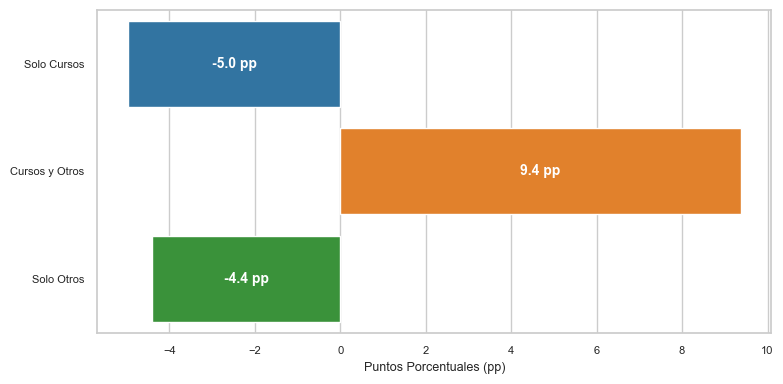

In [223]:
sns.set_theme(style="whitegrid")

# Crear figura con fondo transparente
fig, ax = plt.subplots(figsize=(8, 4), facecolor="none")
ax.set_facecolor("none")

# Lista de colores exactos del gráfico de líneas anterior
colores_exactos = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Generar gráfico horizontal con paleta personalizada
sns.barplot(
    data=resumen_metricas,
    y="indicador",
    x="variacion_absoluta_pp",
    ax=ax,
    palette=colores_exactos,
)

# Configurar títulos y etiquetas con fuentes reducidas
ax.set_title("", fontsize=11, pad=15)
ax.set_xlabel("Puntos Porcentuales (pp)", fontsize=9)
ax.set_ylabel("")

#quiero las etiquetas de los datos dentro de las barras centradas y en color blanco
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width / 2,  # Centrar el texto dentro de la barra
        p.get_y() + p.get_height() / 2,
        f"{width:.1f} pp",
        ha="center",
        va="center",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

# Reducir el tamaño de las letras de los ejes
ax.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.show()


C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\59919952.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


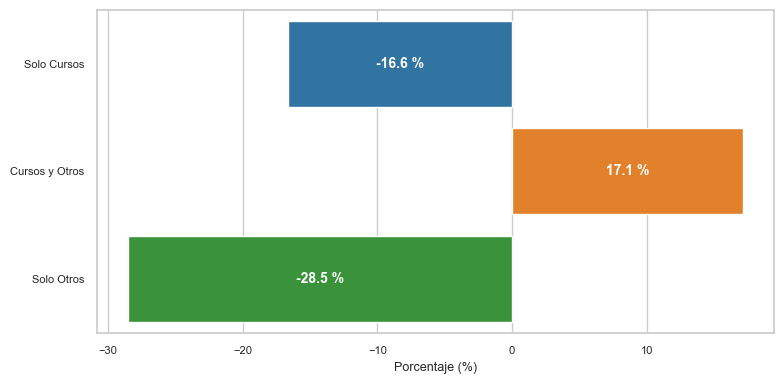

In [ ]:
sns.set_theme(style="whitegrid")

# Crear figura con fondo transparente
fig, ax = plt.subplots(figsize=(8, 4), facecolor="none")
ax.set_facecolor("none")

# Mismos colores para consistencia visual
colores_exactos = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Generar gráfico horizontal de variación relativa
sns.barplot(
    data=resumen_metricas,
    y="indicador",
    x="variacion_relativa_pct",
    ax=ax,
    palette=colores_exactos,
)

# Configurar títulos y etiquetas con fuentes reducidas
ax.set_title("Variación Relativa 2020-2024 (%)", fontsize=11, pad=15)
ax.set_xlabel("Porcentaje (%)", fontsize=9)
ax.set_ylabel("")

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width / 2,  # Centrar el texto dentro de la barra
        p.get_y() + p.get_height() / 2,
        f"{width:.1f} %",
        ha="center",
        va="center",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

# Reducir el tamaño de las letras de los ejes
ax.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.show()



## <span style="font-size:18px; color: orange">**4.7 Estadísticas por sector y años**</span>

### <span style="font-size:16px; color: orange">**4.7.1 Wilcoxon pareado**</span>

In [183]:
ccaa_ = tabla_ccaa_agregado[
    tabla_ccaa_agregado["Comunidad Autónoma"] == "Comunitat Valenciana"
].sort_values("Año")

otros = tabla_ccaa_agregado[
    tabla_ccaa_agregado["Comunidad Autónoma"] == "Cataluña"
].sort_values("Año")

stat, p = wilcoxon(
    ccaa_["Solo Cursos"],
    otros["Cursos y Otros"]
)

print("Estadístico Wilcoxon:", stat)
print("p-valor:", p)

Estadístico Wilcoxon: 0.0
p-valor: 0.0625


In [120]:
ccaa_ = tabla_ccaa_agregado[
    tabla_ccaa_agregado["Comunidad Autónoma"] == "Cataluña"
].sort_values("Año")

otros = tabla_ccaa_agregado[
    tabla_ccaa_agregado["Comunidad Autónoma"] == "Madrid (Comunidad de)"
].sort_values("Año")

stat, p = wilcoxon(
    ccaa_["Solo Otros"],
    otros["Solo Cursos"]
)

print("Estadístico Wilcoxon:", stat)
print("p-valor:", p)

Estadístico Wilcoxon: 1.0
p-valor: 0.125


In [122]:
metodos = ["Solo Cursos", "Cursos y Otros", "Solo Otros"]

for metodo in metodos:
    stat, p = wilcoxon(
        ccaa_[metodo],
        otros[metodo]
    )
    print(f"{metodo} -> estadístico: {stat}, p-valor: {p}")

Solo Cursos -> estadístico: 3.0, p-valor: 0.3125
Cursos y Otros -> estadístico: 5.0, p-valor: 0.625
Solo Otros -> estadístico: 3.0, p-valor: 0.3125


In [123]:
resultados_wilcoxon = []

for metodo in ["Solo Cursos", "Cursos y Otros", "Solo Otros"]:
    stat, p = wilcoxon(ccaa_[metodo], otros[metodo])
    resultados_wilcoxon.append({
        "metodo": metodo,
        "estadistico": stat,
        "p_valor": p
    })

resumen_wilcoxon = pd.DataFrame(resultados_wilcoxon)
print(resumen_wilcoxon)

           metodo  estadistico  p_valor
0     Solo Cursos          3.0   0.3125
1  Cursos y Otros          5.0   0.6250
2      Solo Otros          3.0   0.3125


# <span style="font-size:30px; color: orange">**MEDIOS AÑO 2023-2024**</span>

In [124]:
medios23_24=dataset[(dataset['tabla']=='EAL-18a')]
medios23_24

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
5848,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,total_empresas,TOTAL,TOTAL (2),72.932251
5849,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,tamano_empresa,De 5 a 9 trabajadores,TOTAL (2),64.670730
5850,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,tamano_empresa,De 10 a 49 trabajadores,TOTAL (2),79.013394
5851,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,tamano_empresa,De 50 a 249 trabajadores,TOTAL (2),94.064516
5852,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,tamano_empresa,De 250 a 499 trabajadores,TOTAL (2),98.313930
...,...,...,...,...,...,...,...
8427,2024,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,ccaa,Madrid (Comunidad de),"PARTICIPACIÓN EN CONFERENCIAS, SEMINARIOS, GRU...",38.468204
8428,2024,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,ccaa,Murcia (Región de),"PARTICIPACIÓN EN CONFERENCIAS, SEMINARIOS, GRU...",30.617978
8429,2024,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,ccaa,Navarra (Comunidad Foral de),"PARTICIPACIÓN EN CONFERENCIAS, SEMINARIOS, GRU...",36.736870
8430,2024,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,ccaa,País Vasco,"PARTICIPACIÓN EN CONFERENCIAS, SEMINARIOS, GRU...",36.791976


In [125]:
medios23_24.groupby('variable').count().sort_values(by='categoria', ascending=False)

,anio,tabla,pregunta,ambito,categoria,porcentaje
variable,,,,,,
"APRENDIZAJE PLANIFICADO A PARTIR DE ROTACIÓN DE PUESTOS DE TRABAJO, INTERCAMBIOS, ETC.",64,64,64,64,64,64
CURSOS DE FORMACIÓN DISEÑADOS Y GESTIONADOS POR OTRA ORGANIZACIÓN,64,64,64,64,64,64
CURSOS DE FORMACIÓN DISEÑADOS Y GESTIONADOS POR SU EMPRESA,64,64,64,64,64,64
"FORMACIÓN PLANIFICADA EN EL PUESTO DE TRABAJO, UTILIZANDO LOS MEDIOS HABITUALES DE TRABAJO",64,64,64,64,64,64
"PARTICIPACIÓN EN CONFERENCIAS, SEMINARIOS, GRUPOS DE TRABAJO, TALLERES O FERIAS DE MUESTRAS",64,64,64,64,64,64
TOTAL,32,32,32,32,32,32
TOTAL (2),32,32,32,32,32,32


In [128]:
medios23_24.columns

Index(['anio', 'tabla', 'pregunta', 'ambito', 'categoria', 'variable',
       'porcentaje'],
      dtype='object')

In [144]:
medios23_24["metodo_formacion"] = medios23_24["variable"].replace({
    "CURSOS DE FORMACIÓN DISEÑADOS Y GESTIONADOS POR SU EMPRESA": "Cursos internos",
    "CURSOS DE FORMACIÓN DISEÑADOS Y GESTIONADOS POR OTRA ORGANIZACIÓN": "Cursos externos",
    "FORMACIÓN PLANIFICADA EN EL PUESTO DE TRABAJO, UTILIZANDO LOS MEDIOS HABITUALES DE TRABAJO": "Formación en puesto",
    "APRENDIZAJE PLANIFICADO A PARTIR DE ROTACIÓN DE PUESTOS DE TRABAJO, INTERCAMBIOS, ETC.": "Rotación",
    "PARTICIPACIÓN EN CONFERENCIAS, SEMINARIOS, GRUPOS DE TRABAJO, TALLERES O FERIAS DE MUESTRAS": "Conferencias, seminarios, etc",
    "TOTAL (2)": "Total", 
    "TOTAL": "Total"
})
medios23_24.groupby('metodo_formacion').count().sort_values(by='categoria', ascending=False)

C:\Users\dioul\AppData\Local\Temp\ipykernel_7704\4227913018.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medios23_24["metodo_formacion"] = medios23_24["variable"].replace({


,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
metodo_formacion,,,,,,,
"Conferencias, seminarios, etc",64,64,64,64,64,64,64
Cursos externos,64,64,64,64,64,64,64
Cursos internos,64,64,64,64,64,64,64
Formación en puesto,64,64,64,64,64,64,64
Rotación,64,64,64,64,64,64,64
Total,64,64,64,64,64,64,64


In [145]:
#Filtramos por aquellas empresas que tienen caracteristicas similares a la nuestra, es decir, >499 empleados
medios23_24_grandes = medios23_24[medios23_24['categoria']=='Más de 499 trabajadores']
medios23_24_sector = medios23_24[medios23_24['ambito']=='sector']
medios23_24_comunidad_autonoma = medios23_24[medios23_24['ambito']=='ccaa']

In [146]:
medios23_24_grandes.head(2)

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,metodo_formacion
5853,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,tamano_empresa,Más de 499 trabajadores,TOTAL (2),99.188641,Total
5885,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,tamano_empresa,Más de 499 trabajadores,CURSOS DE FORMACIÓN DISEÑADOS Y GESTIONADOS PO...,85.889571,Cursos internos


In [147]:
medios23_24_sector.head(2)

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,metodo_formacion
5854,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,sector,Industria,TOTAL (2),78.356762,Total
5855,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,sector,Construcción,TOTAL (2),79.310809,Total


In [148]:
medios23_24_comunidad_autonoma.head(2)

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,metodo_formacion
5863,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,ccaa,Andalucía,TOTAL (2),73.308284,Total
5864,2023,EAL-18a,EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TR...,ccaa,Aragón,TOTAL (2),78.902352,Total


In [155]:
def calcular_cambios(df, grupo_col, anio_ini=2023, anio_fin=2024):
    df = df[df["metodo_formacion"] != "Total"].copy()
    wide = (
        df[df["anio"].isin([anio_ini, anio_fin])]
        .pivot_table(index=[grupo_col, "metodo_formacion"], columns="anio", values="porcentaje", aggfunc="mean")
        .reset_index()
    )
    wide["variacion_absoluta"] = wide[anio_fin] - wide[anio_ini]
    wide["variacion_relativa"] = np.where(
        wide[anio_ini] != 0,
        (wide[anio_fin] - wide[anio_ini]) / wide[anio_ini] * 100,
        np.nan
    )
    return wide

In [156]:
cambios_grandes = calcular_cambios(medios23_24_grandes, "categoria")
cambios_sector = calcular_cambios(medios23_24_sector, "categoria")
cambios_ccaa = calcular_cambios(medios23_24_comunidad_autonoma, "categoria")

In [158]:
cambios_sector.head(10)

anio,categoria,metodo_formacion,2023,2024,variacion_absoluta,variacion_relativa
0,Actividades administrativas y servicios auxili...,"Conferencias, seminarios, etc",34.381701,39.518830,5.137129,14.941462
1,Actividades administrativas y servicios auxili...,Cursos externos,76.654753,74.834256,-1.820497,-2.374931
2,Actividades administrativas y servicios auxili...,Cursos internos,36.890636,36.374821,-0.515816,-1.398229
3,Actividades administrativas y servicios auxili...,Formación en puesto,56.933524,60.200943,3.267419,5.739008
4,Actividades administrativas y servicios auxili...,Rotación,25.153681,28.282414,3.128733,12.438469
5,"Actividades artísticas, recreativas y de entre...","Conferencias, seminarios, etc",46.650253,43.228235,-3.422018,-7.335476
6,"Actividades artísticas, recreativas y de entre...",Cursos externos,65.135415,67.162337,2.026922,3.111858
7,"Actividades artísticas, recreativas y de entre...",Cursos internos,37.501620,40.519529,3.017909,8.047409
8,"Actividades artísticas, recreativas y de entre...",Formación en puesto,51.768822,57.172827,5.404004,10.438724
9,"Actividades artísticas, recreativas y de entre...",Rotación,26.247246,24.520269,-1.726977,-6.579651


In [159]:
sns.set_theme(style="whitegrid", context="talk")

colores = {
    "Cursos internos": "#9BF18C",
    "Cursos externos": "#C08C59",
    "Formación en puesto": "#5C615B",
    "Rotación": "#BC62A2",
    "Conferencias, seminarios, etc": "#56E4DB"
}

def graficar_cambios(df, grupo_col, titulo):
    d = df.copy()
    d = d[d["metodo_formacion"] != "Total"]
    d["Etiqueta"] = d[grupo_col].astype(str) + " — " + d["metodo_formacion"].astype(str)
    d = d.dropna(subset=["variacion_absoluta", "variacion_relativa"])

    fig, axes = plt.subplots(1, 2, figsize=(20, max(7, 0.35 * len(d) + 3)), sharey=True)

    for ax, col, ttl, xl in [
        (axes[0], "variacion_absoluta", "Variación absoluta", "Puntos porcentuales"),
        (axes[1], "variacion_relativa", "Variación relativa", "Porcentaje (%)")
    ]:
        dd = d.sort_values([grupo_col, "metodo_formacion"]).copy()
        dd["color"] = dd["metodo_formacion"].map(colores).fillna("#999999")

        bars = ax.barh(dd["Etiqueta"], dd[col], color=dd["color"])
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(ttl, fontweight="bold")
        ax.set_xlabel(xl)
        ax.set_ylabel("")
        ax.grid(axis="x", alpha=0.25)

        for b, v in zip(bars, dd[col]):
            if pd.notna(v):
                ax.text(
                    v + (0.03 if v >= 0 else -0.03),
                    b.get_y() + b.get_height() / 2,
                    f"{v:.1f}",
                    va="center",
                    ha="left" if v >= 0 else "right",
                    fontsize=9
                )

    fig.suptitle(titulo, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

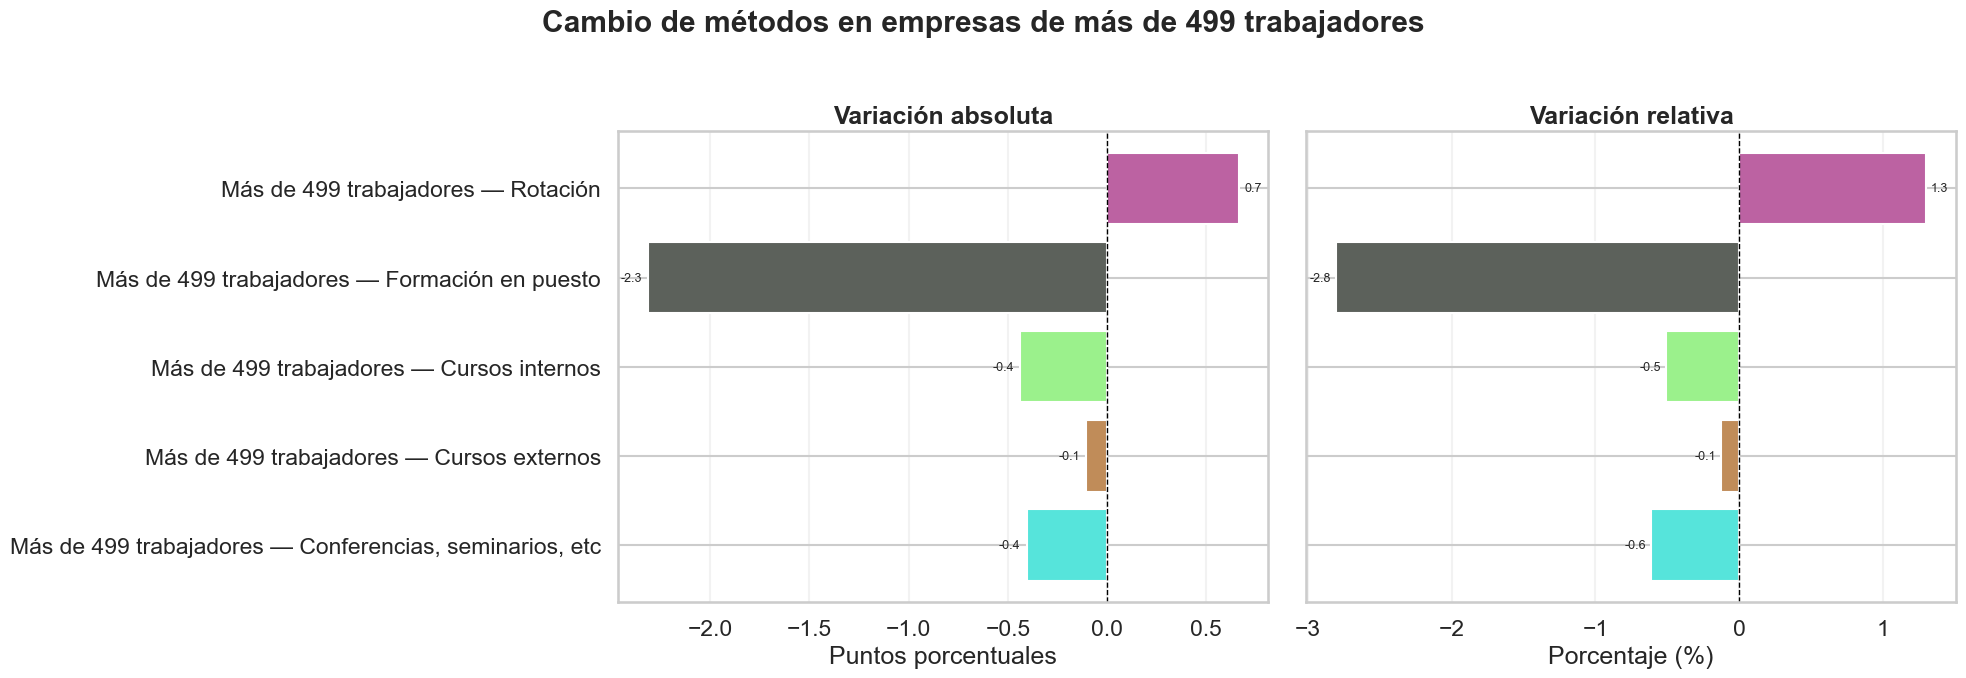

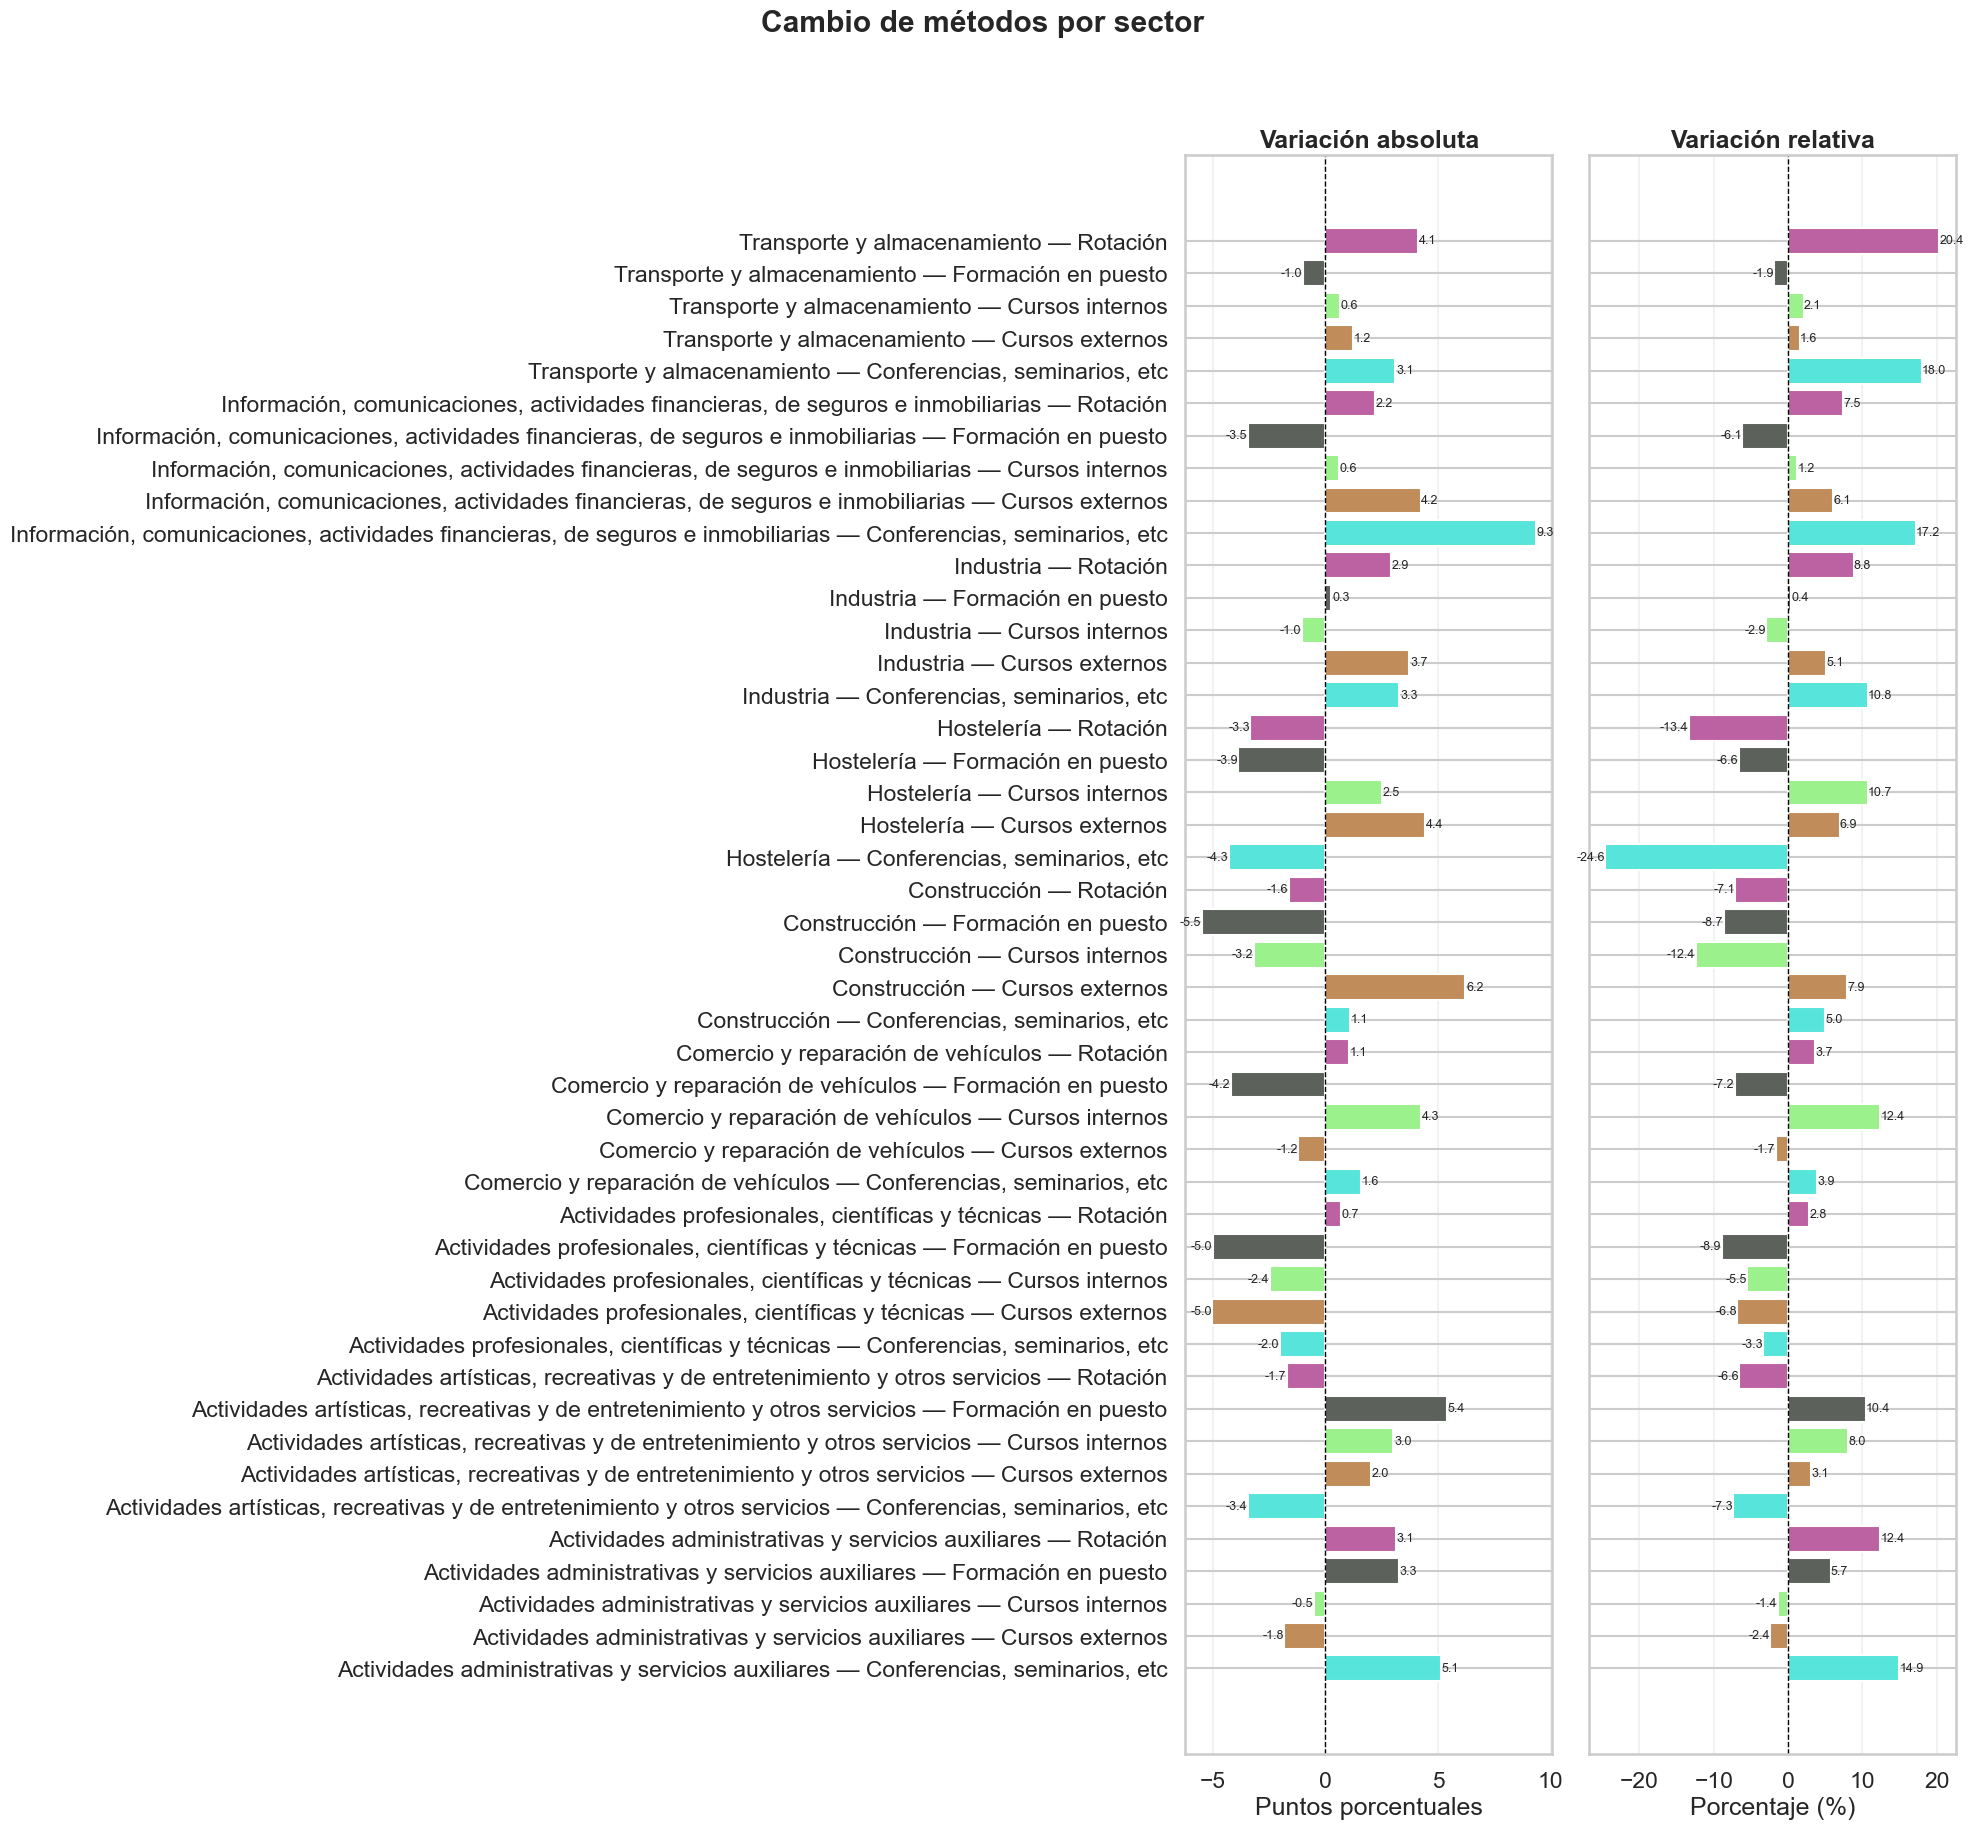

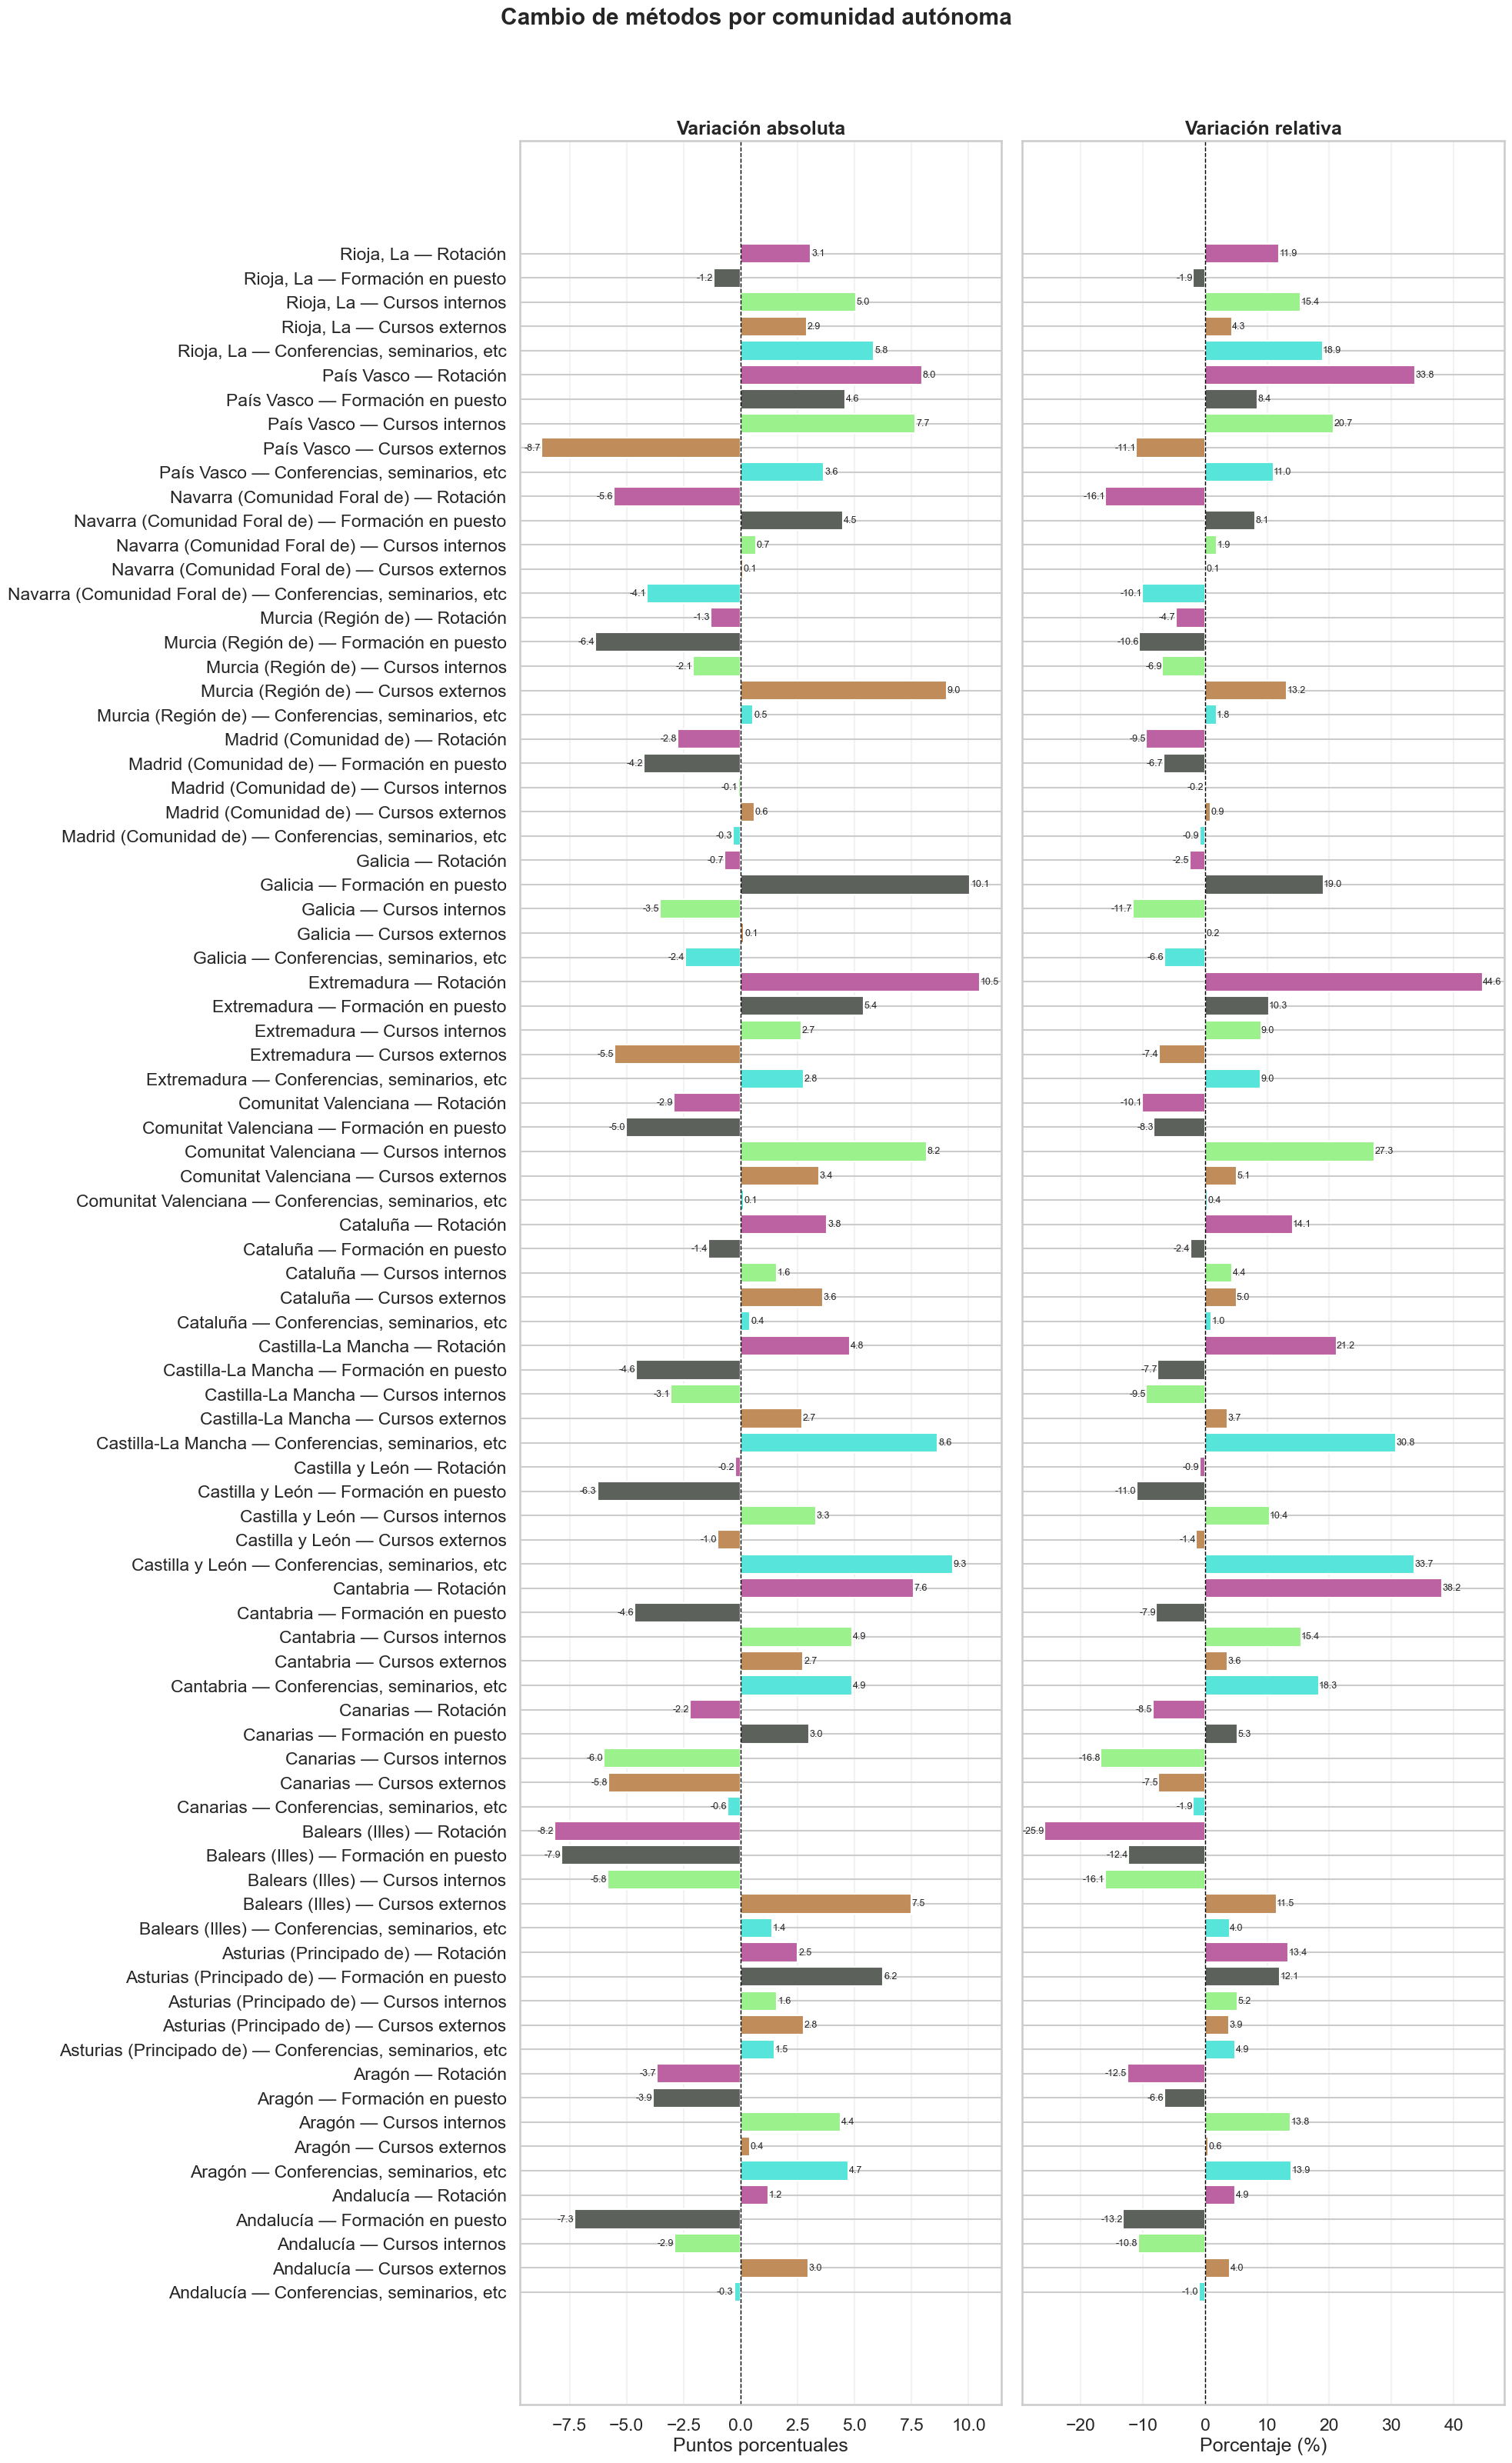

In [160]:
graficar_cambios(cambios_grandes, "categoria", "Cambio de métodos en empresas de más de 499 trabajadores")
graficar_cambios(cambios_sector, "categoria", "Cambio de métodos por sector")
graficar_cambios(cambios_ccaa, "categoria", "Cambio de métodos por comunidad autónoma")

In [161]:
def graficar_cambios(df, grupo_col, titulo):
    d = df.copy()

    # Quitar Total
    d = d[d["metodo_formacion"] != "Total"].copy()

    # Caso 1: sectores -> dejar 3 sectores y agrupar el resto
    if "sector" in titulo.lower():
        sectores_destacados = ["Industria", "Construcción", "Almacenamiento y transporte"]
        d[grupo_col] = np.where(
            d[grupo_col].isin(sectores_destacados),
            d[grupo_col],
            "Resto"
        )

        d = (
            d.groupby([grupo_col, "metodo_formacion"], as_index=False)
             [["variacion_absoluta", "variacion_relativa"]]
             .mean()
        )

    # Caso 2: comunidades autónomas -> filtrar solo las 5 seleccionadas
    if "comunidad" in titulo.lower():
        ccaa_filtradas = [
            "Cataluña",
            "Madrid (Comunidad de)",
            "Andalucía",
            "País Vasco",
            "Comunitat Valenciana"
        ]
        d = d[d[grupo_col].isin(ccaa_filtradas)].copy()

    d["Etiqueta"] = d[grupo_col].astype(str) + " — " + d["metodo_formacion"].astype(str)
    d = d.dropna(subset=["variacion_absoluta", "variacion_relativa"])

    fig, axes = plt.subplots(1, 2, figsize=(20, max(7, 0.35 * len(d) + 3)), sharey=True)

    for ax, col, ttl, xl in [
        (axes[0], "variacion_absoluta", "Variación absoluta", "Puntos porcentuales"),
        (axes[1], "variacion_relativa", "Variación relativa", "Porcentaje (%)")
    ]:
        dd = d.sort_values([grupo_col, "metodo_formacion"]).copy()
        dd["color"] = dd["metodo_formacion"].map(colores).fillna("#999999")

        bars = ax.barh(dd["Etiqueta"], dd[col], color=dd["color"])
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(ttl, fontweight="bold")
        ax.set_xlabel(xl)
        ax.set_ylabel("")
        ax.grid(axis="x", alpha=0.25)

        for b, v in zip(bars, dd[col]):
            if pd.notna(v):
                ax.text(
                    v + (0.03 if v >= 0 else -0.03),
                    b.get_y() + b.get_height() / 2,
                    f"{v:.1f}",
                    va="center",
                    ha="left" if v >= 0 else "right",
                    fontsize=9
                )

    fig.suptitle(titulo, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

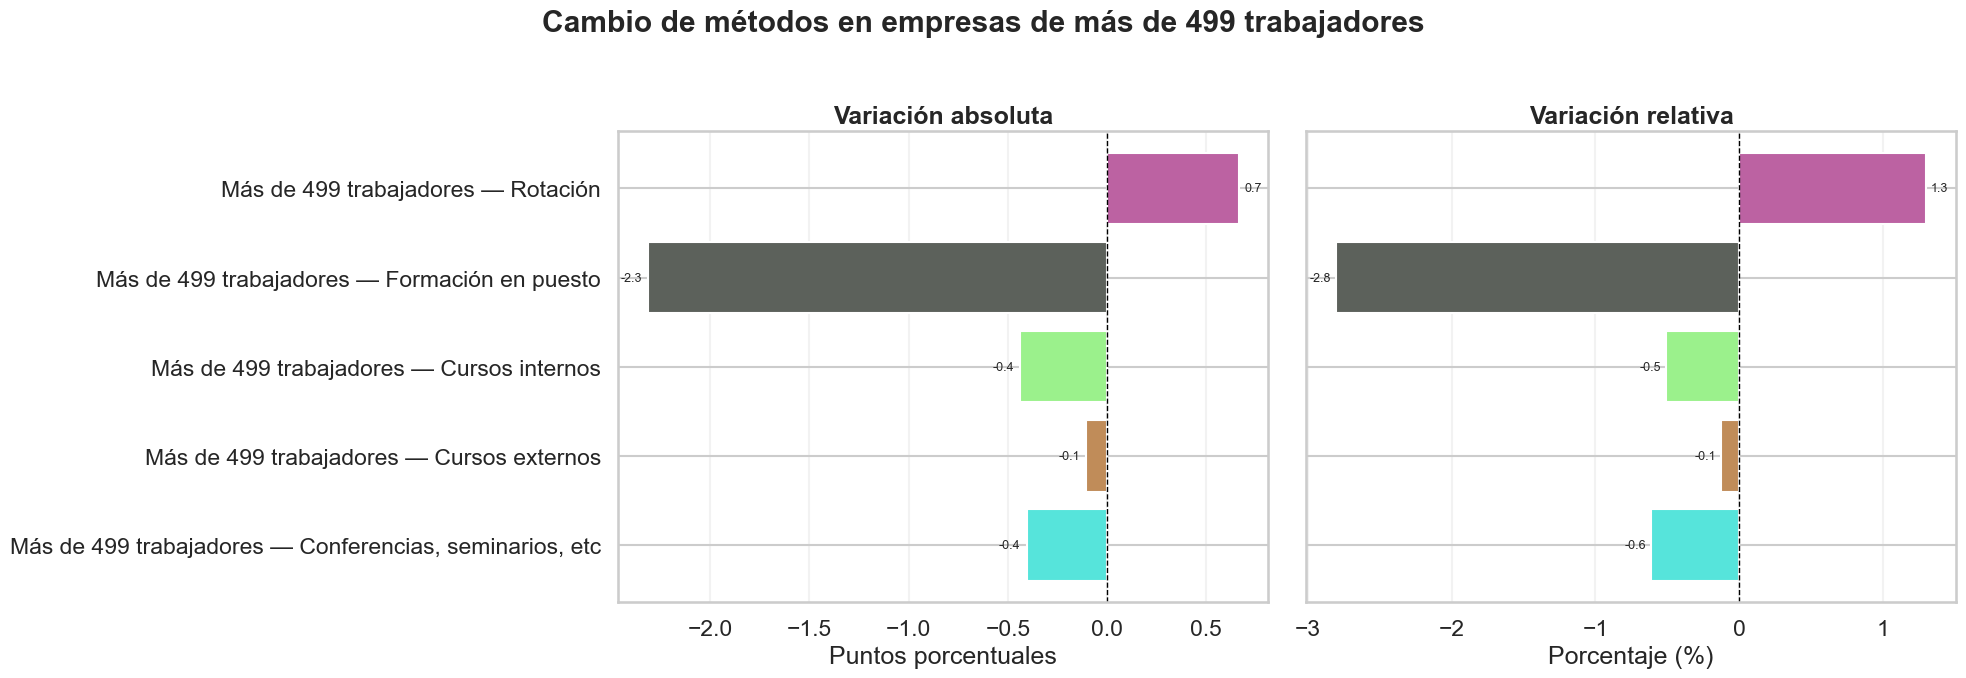

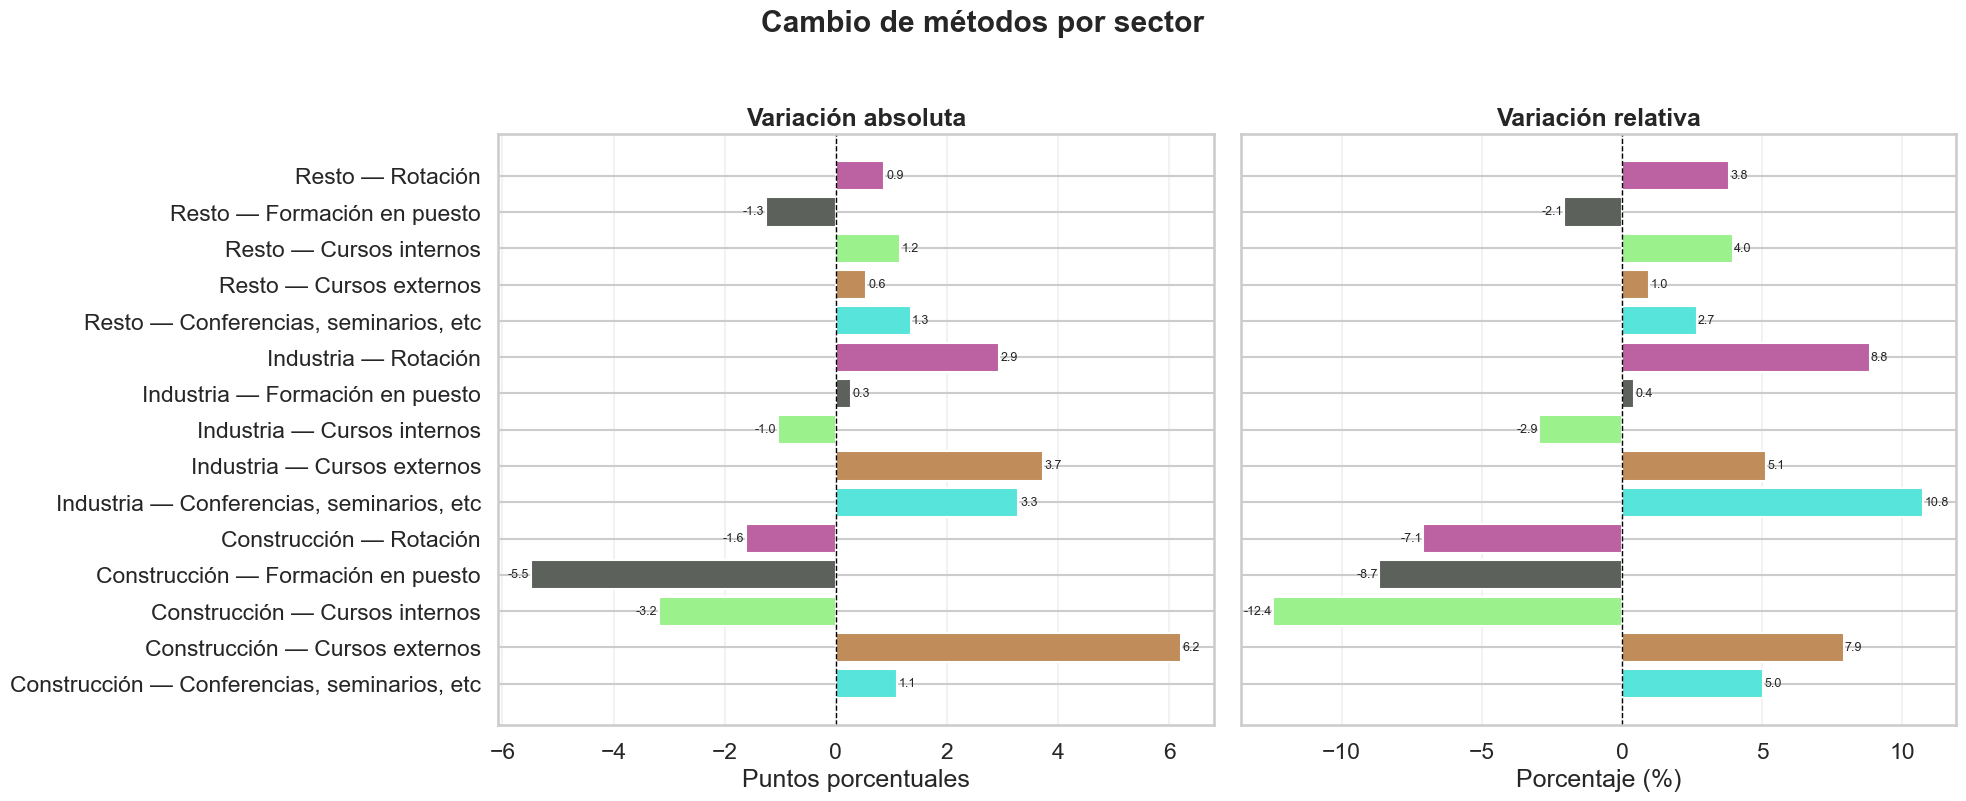

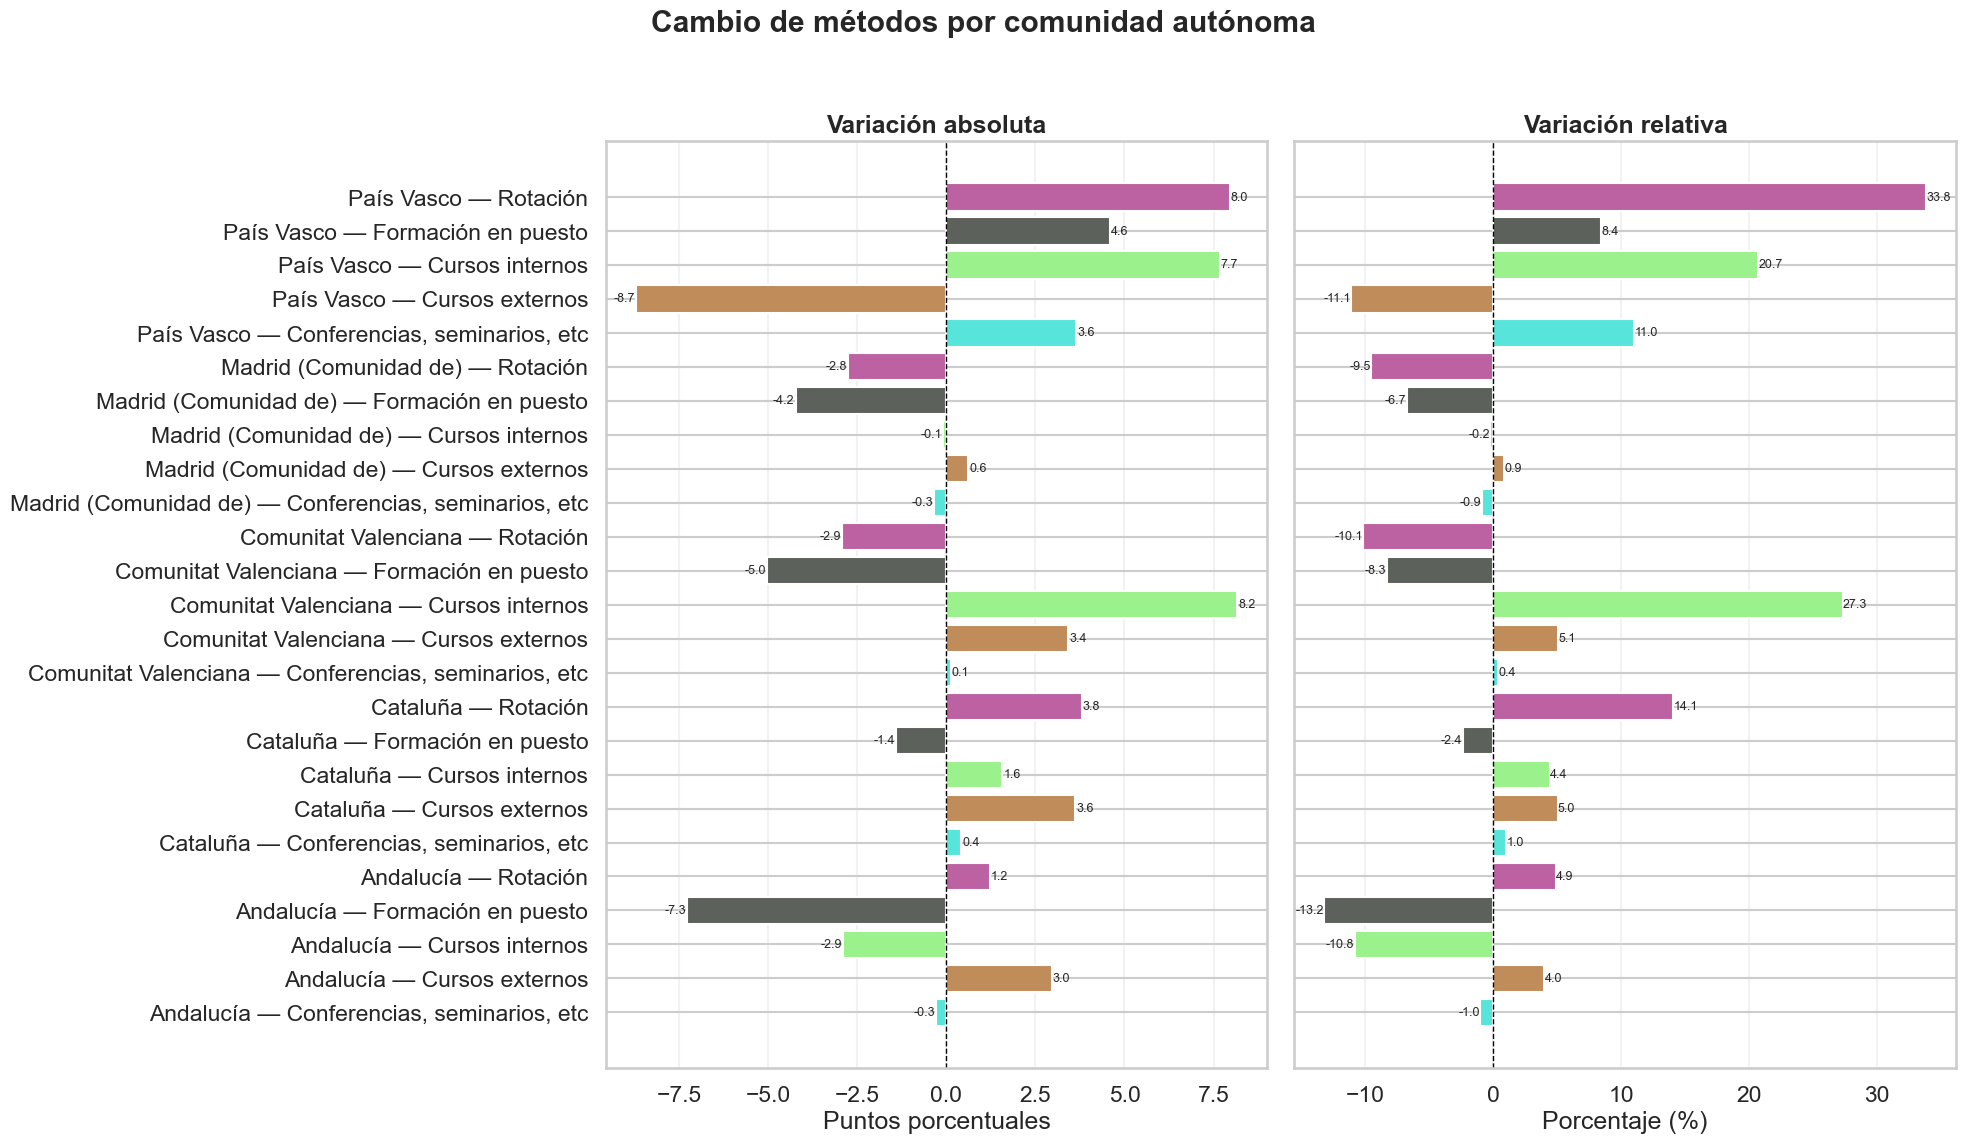

In [162]:
graficar_cambios(cambios_grandes, "categoria", "Cambio de métodos en empresas de más de 499 trabajadores")
graficar_cambios(cambios_sector, "categoria", "Cambio de métodos por sector")
graficar_cambios(cambios_ccaa, "categoria", "Cambio de métodos por comunidad autónoma")

In [212]:
import scipy.stats as stats
import pandas as pd

# 1. Filtrar las comunidades exactamente igual que en tu función gráfica
ccaa_filtradas = [
    "Cataluña",
    "Madrid (Comunidad de)",
    "Andalucía",
    "País Vasco",
    "Comunitat Valenciana"
]
df_stats = cambios_ccaa[cambios_ccaa["categoria"].isin(ccaa_filtradas)].copy()
df_stats = df_stats[df_stats["metodo_formacion"] != "Total"]

# 2. Pivotar la tabla para tener Comunidades como filas y Métodos como columnas
# (Cambia 'variacion_absoluta' por 'variacion_relativa' si prefieres analizar la otra métrica)
df_pivote = df_stats.pivot(
    index="categoria", 
    columns="metodo_formacion", 
    values="variacion_absoluta"
).dropna()

# 3. Ejecutar el test pasando las columnas (los métodos de formación)
# Compara si las filas (Comunidades) tienen diferencias significativas entre sí
stat, p_val = stats.friedmanchisquare(*[df_pivote[col] for col in df_pivote.columns])

print("--- RESULTADO PRUEBA DE FRIEDMAN ---")
print(f"Estadístico: {stat:.4f}")
print(f"p-valor: {p_val:.4f}")

if p_val < 0.05:
    print("¡Resultado Significativo! Existen diferencias reales entre las comunidades.")
else:
    print("No hay diferencias significativas detectadas entre las comunidades autónomas.")


--- RESULTADO PRUEBA DE FRIEDMAN ---
Estadístico: 8.1600
p-valor: 0.0859
No hay diferencias significativas detectadas entre las comunidades autónomas.


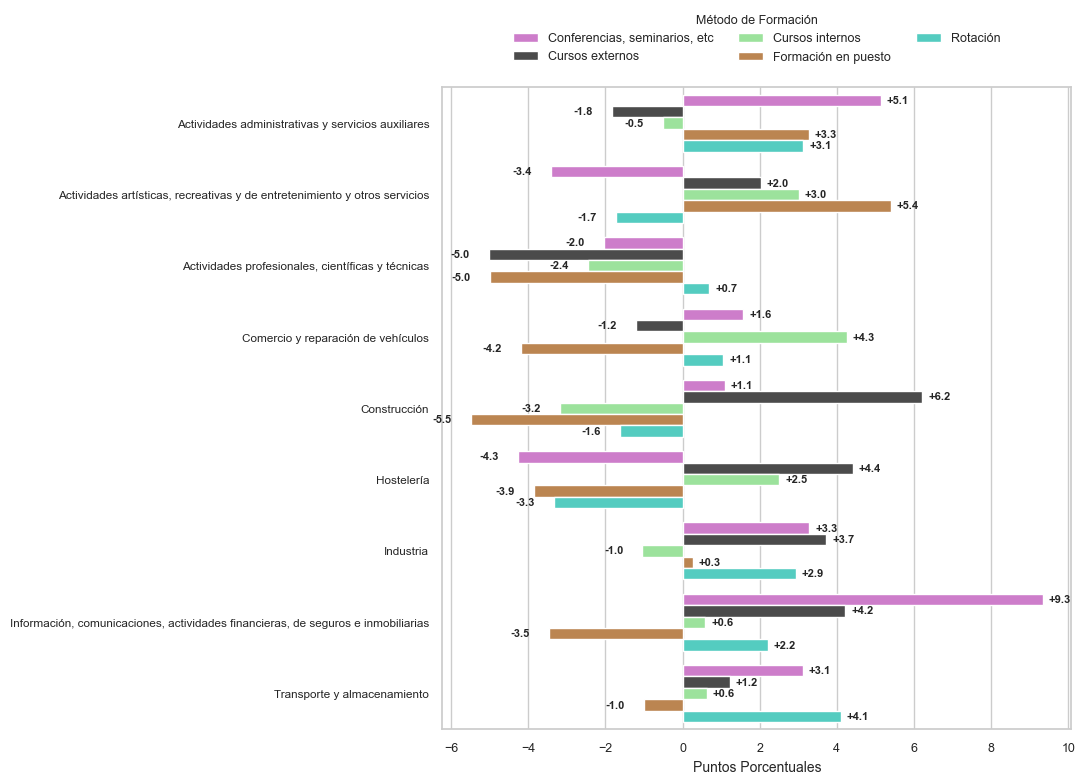

In [167]:
# 1. Ajustar el estilo base
sns.set_theme(style="whitegrid")

# 2. Aumentar significativamente la altura (figsize) para dar espacio a los 9 sectores
fig, ax = plt.subplots(figsize=(11, 8), facecolor="none")
ax.set_facecolor("none")

colores_metodos = ["#da70d6", "#4b4b4b", "#90ee90", "#cd853f", "#40e0d0"]

# 3. Dibujar el gráfico de barras horizontales
sns.barplot(
    data=cambios_sector,  # Usa tu DataFrame con los 9 sectores
    y="categoria", 
    x="variacion_absoluta", 
    hue="metodo_formacion",
    palette=colores_metodos,
    ax=ax
)

# 4. Colocar los valores numéricos de forma inteligente
for p in ax.patches:
    width = p.get_width()
    if abs(width) > 0.1:  # Ignorar valores extremadamente cercanos a 0 para evitar ruido
        # Pequeño ajuste para que los números negativos no queden encima de la barra
        x_pos = width + 0.15 if width >= 0 else width - 0.5
        ax.text(
            x_pos,
            p.get_y() + p.get_height() / 2,
            f"{width:+.1f}",
            va="center", 
            ha="left" if width >= 0 else "right", 
            fontsize=8, 
            fontweight="semibold"
        )

# 5. Títulos y etiquetas compactas
ax.set_title("", fontsize=13, fontweight="bold", pad=25)
ax.set_xlabel("Puntos Porcentuales", fontsize=10)
ax.set_ylabel("")

# Hacer las letras del eje Y un poco más pequeñas debido a la longitud de los textos
ax.tick_params(axis="y", labelsize=8.5)
ax.tick_params(axis="x", labelsize=9)

# 6. TRUCO CLAVE: Mover la leyenda ARRIBA del gráfico horizontalmente para que no tape nada
legend = ax.legend(
    title="Método de Formación", 
    loc="lower center", 
    bbox_to_anchor=(0.5, 1.02),  # Lo sitúa justo encima del recuadro del gráfico
    ncol=3,                      # Distribuye los métodos en 3 columnas horizontales
    frameon=True,
    fontsize=9,
    title_fontsize=9
)
legend.get_frame().set_facecolor("none")
legend.get_frame().set_linewidth(0)

# Ajustar márgenes para que no se corte la leyenda superior
plt.tight_layout()
plt.show()



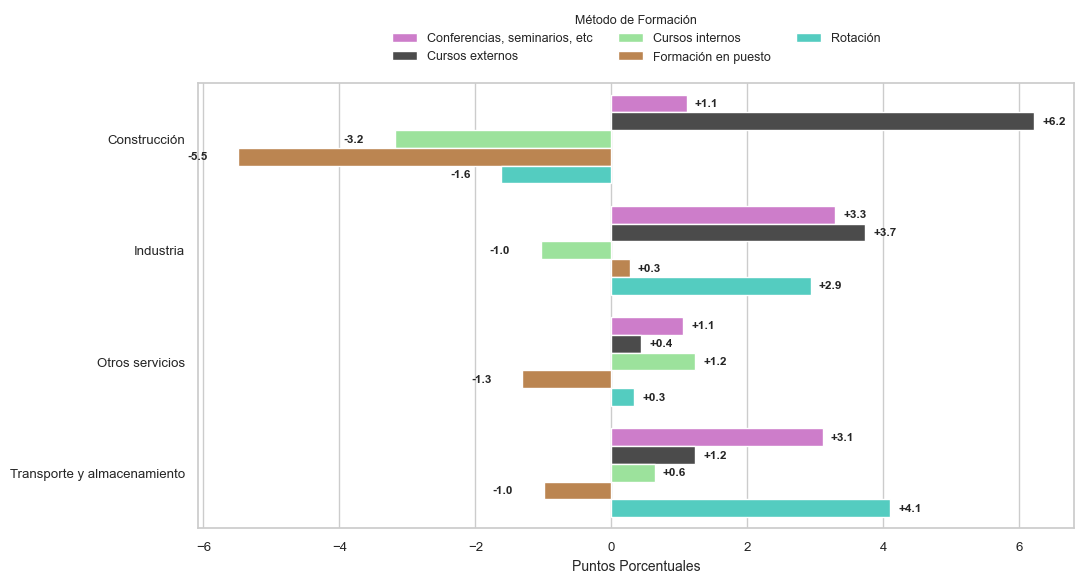

In [213]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear un diccionario de mapeo para agrupar los sectores requeridos
# Nota: Asegúrate de que coincidan con los nombres exactos de tu DataFrame
mapeo_sectores = {
    "Comercio y reparación de vehículos": "Otros servicios",
    "Hostelería": "Otros servicios",
    "Información, comunicaciones, actividades financieras, de seguros e inmobiliarias": "Otros servicios",
    "Actividades artísticas, recreativas y de entretenimiento y otros servicios": "Otros servicios",
    "Actividades administrativas y servicios auxiliares": "Otros servicios",
    "Actividades profesionales, científicas y técnicas": "Otros servicios",
}

# 2. Crear una copia del DataFrame y aplicar la agrupación
df_agrupado = cambios_sector.copy()
df_agrupado["categoria"] = df_agrupado["categoria"].replace(
    mapeo_sectores
)

# 3. Recalcular la media de los datos agrupados para que las barras muestren el valor correcto
# Agrupamos por el nuevo nombre del sector y por el método de formación
df_grafico = (
    df_agrupado.groupby(["categoria", "metodo_formacion"], as_index=False)[
        "variacion_absoluta"
    ]
    .mean()
)

# 4. Configurar el estilo y crear la figura (ahora más compacta al tener menos filas)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 6), facecolor="none")
ax.set_facecolor("none")

colores_metodos = ["#da70d6", "#4b4b4b", "#90ee90", "#cd853f", "#40e0d0"]

# 5. Dibujar el gráfico con la nueva categoría unificada
sns.barplot(
    data=df_grafico,
    y="categoria",
    x="variacion_absoluta",
    hue="metodo_formacion",
    palette=colores_metodos,
    ax=ax,
)

# 6. Colocar los valores numéricos al final de cada barra
for p in ax.patches:
    width = p.get_width()
    if abs(width) > 0.05:
        x_pos = width + 0.12 if width >= 0 else width - 0.45
        ax.text(
            x_pos,
            p.get_y() + p.get_height() / 2,
            f"{width:+.1f}",
            va="center",
            ha="left" if width >= 0 else "right",
            fontsize=8.5,
            fontweight="semibold",
        )

# 7. Estética ejecutiva y Leyenda superior en 3 columnas
ax.set_title(
    "",
    fontsize=12,
    fontweight="bold",
    pad=25,
)
ax.set_xlabel("Puntos Porcentuales", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=9.5)

legend = ax.legend(
    title="Método de Formación",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
    fontsize=9,
    title_fontsize=9,
)
legend.get_frame().set_facecolor("none")
legend.get_frame().set_linewidth(0)

plt.tight_layout()
plt.show()


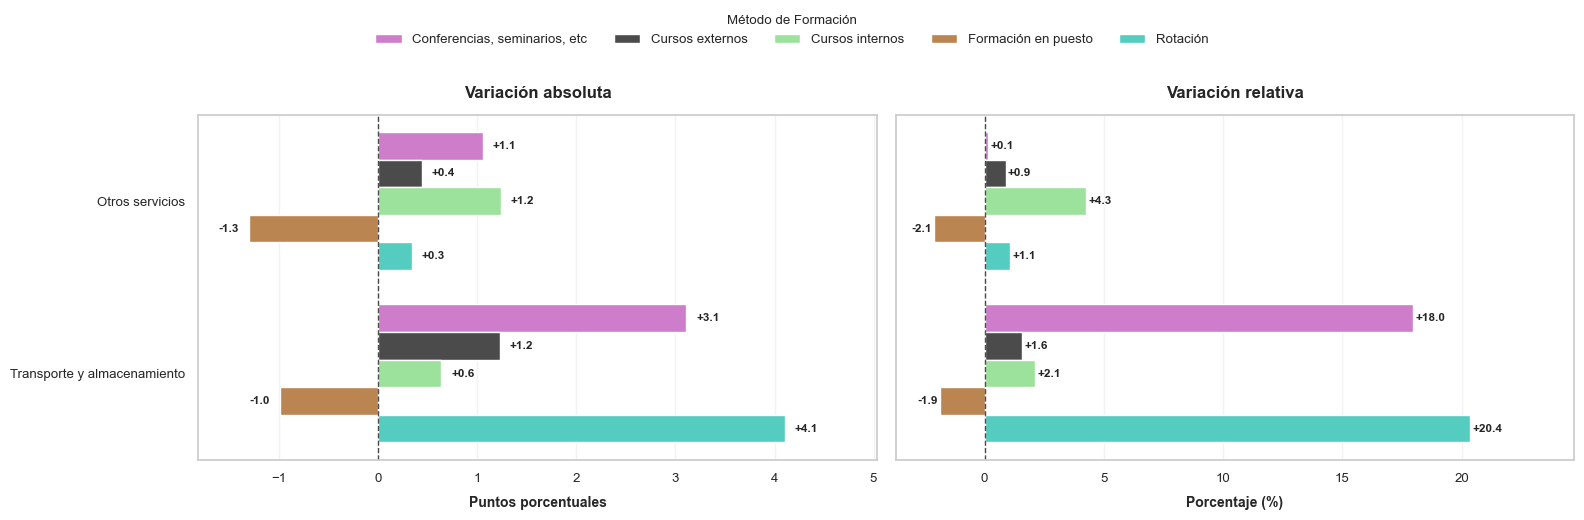

In [215]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Diccionario de mapeo para agrupar en "Otros servicios"
mapeo_sectores = {
    "Comercio y reparación de vehículos": "Otros servicios",
    "Hostelería": "Otros servicios",
    "Información, comunicaciones, actividades financieras, de seguros e inmobiliarias": "Otros servicios",
    "Actividades artísticas, recreativas y de entretenimiento y otros servicios": "Otros servicios",
    "Actividades administrativas y servicios auxiliares": "Otros servicios",
    "Actividades profesionales, científicas y técnicas": "Otros servicios",
}

# 2. Copiar y procesar el DataFrame
df_agrupado = cambios_sector.copy()
df_agrupado = df_agrupado[df_agrupado["metodo_formacion"] != "Total"]

# Aplicar agrupación de sectores
df_agrupado["categoria"] = df_agrupado["categoria"].replace(mapeo_sectores)

# 3. Recalcular las medias incluyendo AMBAS variaciones
df_grafico = (
    df_agrupado.groupby(["categoria", "metodo_formacion"], as_index=False)[
        ["variacion_absoluta", "variacion_relativa"]
    ]
    .mean()
)

# Filtrar para dejar exclusivamente los dos sectores deseados
# Ajusta el texto de "Transporte y almacenamiento" si en tus datos se llama distinto
sectores_deseados = ["Otros servicios", "Transporte y almacenamiento"]
df_grafico = df_grafico[df_grafico["categoria"].isin(sectores_deseados)].copy()

# 4. Configurar el estilo base y la figura con fondo transparente
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True, facecolor="none")

colores_metodos = ["#da70d6", "#4b4b4b", "#90ee90", "#cd853f", "#40e0d0"]

# Configuraciones para cada columna de datos
metricas = [
    ("variacion_absoluta", "Variación absoluta", "Puntos porcentuales", axes[0]),
    ("variacion_relativa", "Variación relativa", "Porcentaje (%)", axes[1])
]

# 5. Iterar para pintar ambos gráficos (Absoluta y Relativa)
for col, ttl, xl, ax in metricas:
    ax.set_facecolor("none")  # Fondo del gráfico transparente
    
    # Dibujar barras usando Seaborn
    sns.barplot(
        data=df_grafico,
        y="categoria",
        x=col,
        hue="metodo_formacion",
        palette=colores_metodos,
        ax=ax,
    )
    
    # Línea de referencia en el cero
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    
    # Títulos de los ejes en NEGRITA
    ax.set_title(ttl, fontweight="bold", fontsize=12, pad=12)
    ax.set_xlabel(xl, fontweight="bold", fontsize=10, labelpad=8)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=9.5)
    ax.grid(axis="x", alpha=0.25)
    
    # Quitar leyendas individuales de los subgráficos para unificarlas después
    if ax.get_legend():
        ax.get_legend().remove()

    # 6. Colocar los valores numéricos controlando que no se salgan del recuadro
    for p in ax.patches:
        width = p.get_width()
        if pd.notna(width) and abs(width) > 0.01:
            # Determinamos el desplazamiento y alineación según el signo
            # Reducimos los márgenes para asegurar que queden dentro del recuadro de la gráfica
            x_pos = width + 0.1 if width >= 0 else width - 0.1
            alignment = "left" if width >= 0 else "right"
            
            ax.text(
                x=x_pos,
                y=p.get_y() + p.get_height() / 2,
                s=f"{width:+.1f}",
                va="center",
                ha=alignment,
                fontsize=8.5,
                fontweight="semibold",
            )
            
    # CORRECCIÓN DE MÁRGENES INTERNOS: Añadir holgura a los límites de los ejes (Xmax y Xmin) 
    # para que las etiquetas de texto impresas no queden cortadas por fuera del área visible.
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.15 if xmin < 0 else xmin, xmax * 1.15 if xmax > 0 else xmax)

# 7. Crear una leyenda única global en la parte superior
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(
    handles,
    labels,
    title="Método de Formación",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=5,
    frameon=True,
    fontsize=9.5,
    title_fontsize=9.5
)
legend.get_frame().set_facecolor("none")
legend.get_frame().set_linewidth(0)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

